# **Probabilistic Machine-Learning (PML) Data Analysis**

## Data Analysis Notebook for all calculated stock features

### Covers 26 feature categories from 63 calc_* functions:

  1. Valuation Ratios (4 functions)
  2. Momentum (2 functions)
  3. Technical Analysis (1 function)
  4. Profitability (4 functions)
  5. Earnings (6 functions)
  6. Growth (5 functions) - includes Revenue Estimate Consensus
  7. Quality & Risk (5 functions)
  8. Leverage & Liquidity (6 functions)
  9. Analyst Sentiment (3 functions) - includes Price Target Achievement
  10. Dividends (3 functions)
  11. Employment (2 functions)
  12. Cash Flow (5 functions) - includes FCF Growth Estimates
  13. Temporal (2 functions)
  14. Balance Sheet (3 functions)
  15. Cost Structure (3 functions)
  16. Composite Scores (2 functions)
  17. Unusual Items (1 function)
  18. Volatility Surface (1 function)
  19. Tax Rate Features (1 function)
  20. OpEx Temporal (1 function)
  21. Asset Sale Features (1 function)
  22. FCF Estimate Curve (1 function)
  23. Dividend History (1 function)
  24. Investment Income Temporal (1 function)
  25. Share Dilution Tracking (1 function)
  26. Forward Consensus (1 function)
  27. Price Target Achievement (1 function)
  28. Size & Liquidity (1 function)
  29. FCF Growth Estimates (1 function)

Direct reference columns include: Enhancement 1 (17 cols), Enhancement 6 (6 cols),

## 1. Setup & Data Loading

In [1]:
# ── Configure PyTensor to use Python-only mode (must run before any PyMC import) ──
# On Windows with MSVC-built CPython 3.14, MinGW g++ cannot reliably link against
# python314.dll due to ABI incompatibility.  Setting cxx="" disables C compilation
# entirely and uses PyTensor's pure-Python VM.
import os

os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from probabilistic_ml_model.statistical_functions.screening import (
    create_enhanced_screener,
    screen_value_opportunities,
    screen_growth_momentum,
    screen_dividend_quality,
    screen_financial_health,
    rank_stocks_by_composite_score,
)
from probabilistic_ml_model.statistical_functions.statistical_models import (
    bayesian_category_analysis,
    fit_distributions_by_category,
)

# Core PML Models (Bayesian / PyMC)
from probabilistic_ml_model.pymc_models.AccountingAnomalyModel import AccountingAnomalyBayesian
from probabilistic_ml_model.pymc_models.CreditRiskModel import CreditRiskBayesian
from probabilistic_ml_model.pymc_models.DividendSafetyModel import DividendSafetyBayesian
from probabilistic_ml_model.pymc_models.EarningsBeatModel import EarningsBeatBayesian
from probabilistic_ml_model.pymc_models.KalmanFilterModel import KalmanFilterPriceTarget
from probabilistic_ml_model.pymc_models.PriceTargetModel import PriceTargetAchievement

import arviz as az
from probabilistic_ml_model.visualizations.probability_viz import (
    create_beat_probability_posterior,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

COLORS = {
    "primary": "#264653",
    "secondary": "#2A9D8F",
    "accent": "#E9C46A",
    "danger": "#E76F51",
    "info": "#457B9D",
    "light": "#F4A261",
}

arviz_plots not available; arviz.plots shim will be empty


## 2. Data Overview & Quality Assessment

In [3]:
%%sql
select * from public.mv_exp_returns_df

,isin,ticker,name,description,region,country,trading_country,exchange,sector,industry,dividend_record_frequency,earnings_report_frequency,fy_end,next_earnings_report,next_earnings_status,next_earnings_when,next_fiscal_quarter,reporting_interval,size_class,style_class,unit,dividend_record_announce_date,dividend_record_ex_date,dividend_record_payable_date,dividend_record_record_date,fy_end_date,income_statement_report_date,last_updated,next_earnings,next_fy_end_date,...,pt_accuracy_1y,pt_optimism_bias,pt_range_hit_rate,pt_median_vs_mean_spread,pt_high_low_convergence_1y,analyst_count_stability,log_market_cap,daily_turnover_ratio,liquidity_score,fcf_est_fy1,fcf_est_fy2,fcf_est_fy3,fcf_est_fy4,fcf_est_fy5,fcf_est_growth_fy1_vs_ltm,fcf_est_growth_fy2_vs_fy1,fcf_est_growth_fy3_vs_fy2,fcf_est_growth_fy4_vs_fy3,fcf_est_growth_fy5_vs_fy4,fcf_est_cagr_3y,fcf_est_cagr_5y_fwd,fcf_est_margin_fy1,fcf_est_yield_fy1,fcf_est_growth_acceleration,fcf_est_growth_deceleration,fcf_est_trajectory_score_fwd,fcf_est_always_positive_fwd,fcf_est_vs_historical,fcf_est_capex_implied_ratio,feature_calculated_at
0,US0378331005,AAPL,Apple Inc.,Apple Inc. designs manufactures and markets sm...,United States and Canada,US,US,NasdaqGS,Information Technology,Technology Hardware Storage and Peripherals,Quarterly,Quarterly,Sep 2025,Interim,Estimated,After-Market,Q1 2026,3.0000,Large Cap,Core,USD,2026-01-29,2026-02-09,2026-02-12,2026-02-09,2025-09-30,2025-12-27,2026-04-24,2026-04-30,2026-09-30,...,0.1463,-0.1463,1,-0.0076,-0.1010,0.9677,15.1967,0.0026,2259798.6604,136028.3300,149910.2400,165583.5500,175520.5800,188318.0400,10.3016,10.2052,10.4551,6.0012,7.2911,10.3206,8.8351,31.2266,3.4183,-0.0964,0,100,1,19.5289,1.1030,2026-04-26 18:10:26.730718+02
1,US5949181045,MSFT,Microsoft Corporation,Microsoft Corporation develops and supports so...,United States and Canada,US,US,NasdaqGS,Information Technology,Software,Quarterly,Semi-Annually,Jun 2025,Full Year,Confirmed,After-Market,Q2 2026,6.0000,Large Cap,Core,USD,2026-03-10,2026-05-21,2026-06-11,2026-05-21,2025-06-30,2025-12-31,2026-04-24,2026-04-29,2026-06-30,...,0.1364,0.1364,1,-0.0163,0.0872,1.0385,14.9639,0.0037,1467928.7211,70066.2700,76527.8500,92675.0000,125823.4000,174348.0000,-9.4891,9.2221,21.0997,35.7684,38.5656,6.1821,17.6310,22.9385,2.2222,18.7112,0,100,1,-6.1680,0.9051,2026-04-26 18:10:26.730718+02
2,US30054Y1073,EVMN,Evommune Inc.,Evommune Inc. operates as a clinical-stage bio...,United States and Canada,US,US,NYSE,Health Care,Biotechnology,NaN,Annually,Dec 2025,Full Year,Estimated,After-Market,Q4 2027,12.0000,Small Cap,Core,USD,NaN,NaN,NaN,NaN,2025-12-31,2025-12-31,2026-04-24,2026-06-11,2026-12-31,...,NaN,NaN,0,-0.0082,NaN,3.5000,6.8180,0.0072,41867.1492,-105.6600,-122.5200,-150.4900,-188.8000,-206.2300,-37.7934,-15.9568,-22.8289,-25.4568,-9.2320,NaN,NaN,-812.7692,-11.5583,21.8366,0,0,0,-6.2217,-1.3864,2026-04-26 18:10:26.730718+02
3,US0231351067,AMZN,Amazon.com Inc.,Amazon.com Inc. engages in the retail sale of ...,United States and Canada,US,US,NasdaqGS,Consumer Discretionary,Broadline Retail,NaN,Annually,Dec 2025,Full Year,Estimated,After-Market,Q4 2027,12.0000,Large Cap,Core,USD,NaN,NaN,NaN,NaN,2025-12-31,2025-12-31,2026-04-24,2026-04-29,2026-12-31,...,0.0719,-0.0719,1,-0.0041,0.2736,0.9897,14.8590,0.0050,4704935.8635,-20124.0900,48551.9100,81599.8000,99249.0000,141282.0000,-361.5216,341.2626,68.0671,21.6290,42.3511,119.6984,78.9681,-2.8070,-0.7088,702.7843,0,80,0,-284.9263,-2.6152,2026-04-26 18:10:26.730718+02
4,GB00BSLKLP68,BBSN,Brave Bison Group plc,Brave Bison Group plc provides digital adverti...,Europe,GB,GB,AIM,Communication Services,Interactive Media and Services,Annual,Quarterly,Dec 2024,Interim,Confirmed,Pre-Market,Q2 2025,3.0000,Small Cap,Core,GBP,2025-04-10,2025-05-29,2025-07-01,2025-05-30,2024-12-31,2025-06-30,2026-04-24,2026-04-30,2025-12-31,...,0.1915,0.1915,0,0.0000,0.0328,1.5000,4.7487,0.0012,35748.0103,17.3100,-1.5100,0.0000,0.0000,0.0000,3084.4828,-108.7233,100.0000,NaN,NaN,NaN,NaN

In [4]:
%%sql
select cfr.category,cfr.feature_alias, cfr.calculation_type from public.calculated_features_registry cfr
where category <> 'Identifier' and category <> 'Market Data';

,category,feature_alias,calculation_type
0,Interest Income,interest_income_yoy_growth,growth
1,Accounting Quality,asset_sale_gain_loss_ltm,direct
2,Quality & Risk,net_buyback_flag,flag
3,Analyst Sentiment,ebitda_est_fy1e,direct
4,Analyst Sentiment,analyst_count_stability,ratio
...,...,...,...
802,Valuation Ratios,tangible_asset_quality,direct
803,Valuation Ratios,tangible_book_value_fy,direct
804,Valuation Ratios,tangible_book_value_ltm,direct
805,Valuation Ratios,tbv_vs_calculated,direct


In [5]:
# Build a proper dictionary from the DataFrame: {category: [feature_alias, ...]}
FEATURE_CATEGORIES = feature_cat.groupby("category")["feature_alias"].apply(list).to_dict()

print(f"Dataset shape: {df.shape[0]} stocks × {df.shape[1]} features")
print(f"Feature categories: {len(FEATURE_CATEGORIES)}")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")

Dataset shape: 6668 stocks × 831 features
Feature categories: 27

Column dtypes:
float64    694
int64      105
str         32
Name: count, dtype: int64


In [6]:
# Identifier columns overview
id_cols = ["isin", "name", "industry", "sector", "next_earnings"]
available_ids = [c for c in id_cols if c in df.columns]
print("Identifier columns available:", available_ids)
df[available_ids].head(10)

Identifier columns available: ['isin', 'name', 'industry', 'sector', 'next_earnings']


,isin,name,industry,sector,next_earnings
0,US0378331005,Apple Inc.,Technology Hardware Storage and Peripherals,Information Technology,2026-04-30
1,US5949181045,Microsoft Corporation,Software,Information Technology,2026-04-29
2,US30054Y1073,Evommune Inc.,Biotechnology,Health Care,2026-06-11
3,US0231351067,Amazon.com Inc.,Broadline Retail,Consumer Discretionary,2026-04-29
4,GB00BSLKLP68,Brave Bison Group plc,Interactive Media and Services,Communication Services,2026-04-30
5,US88160R1014,Tesla Inc.,Automobiles,Consumer Discretionary,2026-07-22
6,US03969F1093,Arcus Biosciences Inc.,Biotechnology,Health Care,2026-05-05
7,US5324571083,Eli Lilly and Company,Pharmaceuticals,Health Care,2026-04-30
8,US74982T1034,RXO Inc.,Ground Transportation,Industrials,2026-05-07
9,CA6744822033,Obsidian Energy Ltd.,Oil Gas and Consumable Fuels,Energy,2026-05-07


In [7]:
# Missing data analysis per feature category
missing_report = {}
for cat, cols in FEATURE_CATEGORIES.items():
    present = [c for c in cols if c in df.columns]
    if present:
        pct_missing = df[present].isnull().mean().mean() * 100
        missing_report[cat] = {
            "defined": len(cols),
            "present": len(present),
            "avg_missing_pct": round(pct_missing, 1),
        }

missing_df = pd.DataFrame(missing_report).T.sort_values("avg_missing_pct", ascending=False)
missing_df

,defined,present,avg_missing_pct
Employee Productivity,7.0000,7.0000,26.8000
Dividend Reliability,34.0000,34.0000,23.4000
Valuation Timeseries,23.0000,22.0000,16.2000
EPS Trajectory,11.0000,11.0000,13.6000
GAAP vs Adjusted,50.0000,50.0000,13.3000
Employment Dynamics,10.0000,10.0000,12.7000
Efficiency Ratios,45.0000,45.0000,11.5000
Cash Flow,59.0000,57.0000,9.7000
Enhanced Cash Flow,28.0000,28.0000,9.3000
Valuation Ratios,17.0000,16.0000,8.7000


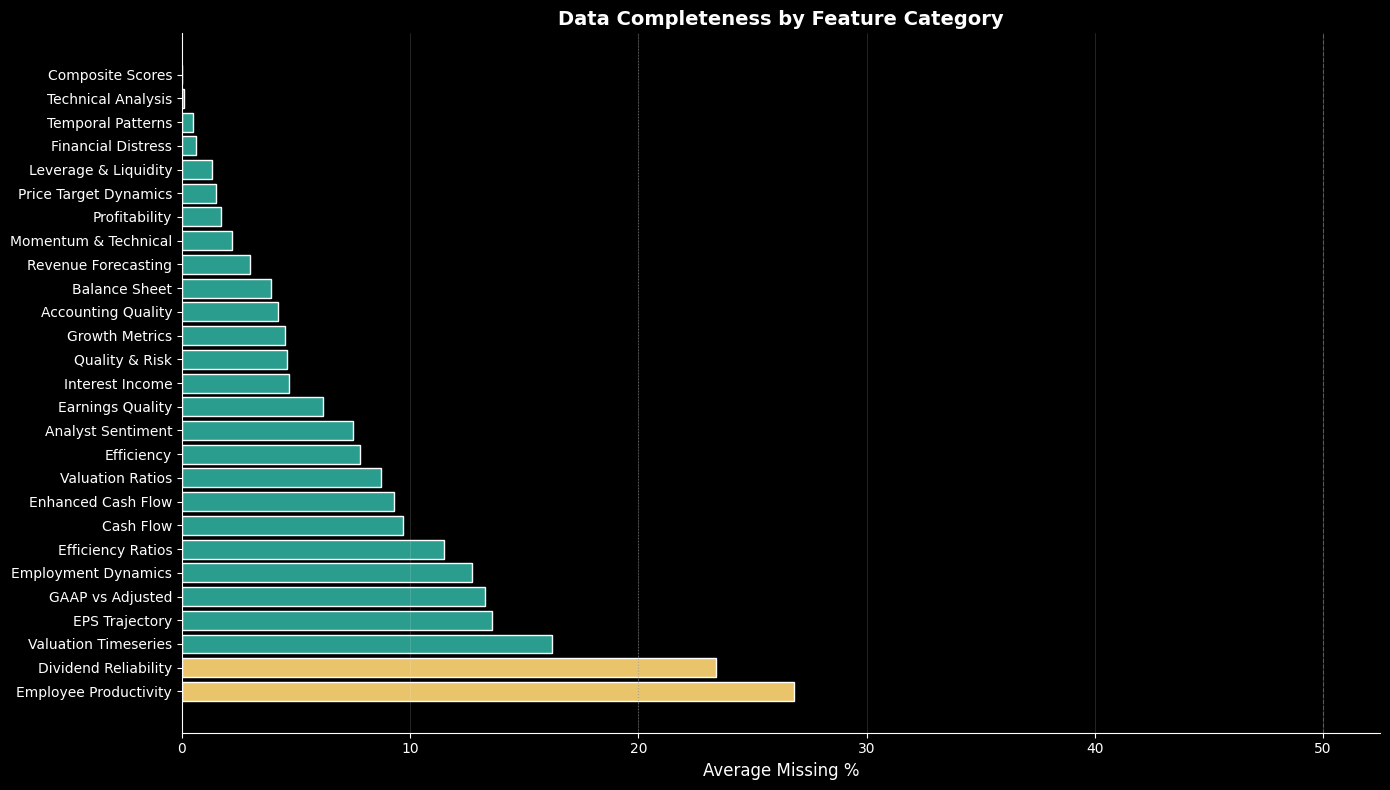

In [8]:
# Visualize missing data by category
fig, ax = plt.subplots(figsize=(14, 8))
colors_bar = [
    COLORS["danger"] if v > 50 else COLORS["accent"] if v > 20 else COLORS["secondary"]
    for v in missing_df["avg_missing_pct"]
]
bars = ax.barh(missing_df.index, missing_df["avg_missing_pct"], color=colors_bar, edgecolor="white")
ax.set_xlabel("Average Missing %", fontsize=12)
ax.set_title("Data Completeness by Feature Category", fontsize=14, fontweight="bold")
ax.axvline(20, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
ax.axvline(50, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Descriptive Statistics by Feature Category

In [9]:
# Summary statistics for each category
for cat_name in FEATURE_CATEGORIES:
    cols = [c for c in FEATURE_CATEGORIES.get(cat_name, []) if c in df.columns]
    if cols:
        print(f"\n{'=' * 60}")
        print(f"  {cat_name} ({len(cols)} features)")
        print(f"{'=' * 60}")
        display(df[cols].describe().round(3))


  Accounting Quality (46 features)


,asset_sale_gain_loss_ltm,asset_sale_frequency,asset_sale_trend,effective_tax_rate_fy,tax_rate_yoy_change,tax_rate_qoq_change,tax_rate_stability,low_tax_flag,tax_rate_trend_4q,effective_tax_rate_ltm,goodwill_change_rate,restructuring_intensity,exceptional_items_frequency,merger_impact_ratio,non_operating_income_share,asset_sale_boost,accounting_quality_score,goodwill_2fq,goodwill_2fy,goodwill_3fq,goodwill_3fy,goodwill_1fy,goodwill_3y_growth,goodwill_4fq,goodwill_4fy,goodwill_accumulation_rate,goodwill_concentration,goodwill_fy,goodwill_ltm,goodwill_qoq_change,goodwill_to_assets_trend,goodwill_vs_5y_avg,goodwill_yoy_change,impairment_risk_score,recent_acquisition_flag,asset_writedown_frequency,asset_writedown_ltm,exceptional_items_total_ltm,goodwill_impairment_frequency,goodwill_impairment_ltm,has_goodwill_impairment_ltm,quality_issues_count_5y,restructuring_frequency,restructuring_ltm,goodwill_1fq,goodwill_fq
count,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,4705.0000,6348.0000,6668.0000,6668.0000,6660.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,4577.0000,6668.0000,6668.0000,4577.0000,6633.0000,6668.0000,6668.0000,4107.0000,6593.0000,4801.0000,4705.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000
mean,8.5040,4.1450,-3.5650,0.2330,-0.0800,-0.0310,0.4400,0.3300,-0.0280,0.2640,19.9040,-0.0020,0.5680,-0.0040,0.2800,0.3070,85.6870,985.2270,1024.7710,942.5580,988.8350,1037.8660,779.1950,992.0780,960.7940,7.0270,24.3130,1098.7210,1068.7190,3.7880,-0.0710,1.1200,2000.2670,16.4600,0.0190,1.9970,-30.9590,72.5750,0.4040,-15.7730,0.0810,3.2820,0.8810,-21.6460,1010.8620,1061.4070
std,226.1710,3.8560,188.4350,1.1400,4.7590,2.3760,3.7900,0.4700,1.6560,2.0860,1259.0670,0.0070,0.6980,0.0290,2.6290,0.4610,16.9610,4490.6370,4211.8610,4231.6750,4096.0610,4476.3230,21686.8670,4448.8420,4062.0240,76.1510,219.0100,4651.0580,4675.1250,217.6080,3.6730,9.0330,125907.3160,29.0290,0.1350,2.0400,305.9440,494.3920,0.9340,194.3470,0.2730,3.0990,1.6570,290.8990,4371.8770,4638.8950
min,-11049.1100,0.0000,-13005.0720,0.0000,-307.5180,-142.4750,0.0000,0.0000,-61.2130,0.0000,-3.2210,-0.1830,0.0000,-0.9980,0.0000,0.0000,20.0000,-1.0100,0.0000,-1.0700,0.0000,0.0000,-100.0000,-0.0400,0.0000,-100.0000,-11438.3840,-1.0100,-1.9100,-100.0000,-53.0280,0.0000,-217.4420,0.0000,0.0000,0.0000,-16440.3400,0.0000,0.0000,-6734.0000,0.0000,0.0000,0.0000,-20197.3700,-1.7800,-1.9100
25%,0.0000,0.0000,-0.0280,0.0000,-0.0330,-0.0290,0.0210,0.0000,-0.0540,0.0040,-0.0150,0.0000,0.0000,-0.0000,0.0150,0.0000,75.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-8.7840,0.0000,0.0000,-3.0180,0.0000,0.0000,0.0000,-0.7340,-0.2840,0.4750,0.0000,0.0000,0.0000,0.0000,-2.5250,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,4.0000,0.0000,0.1630,0.0000,0.0000,0.0880,0.0000,0.0000,0.1920,0.0400,0.0000,0.0000,0.0000,0.0550,0.0000,90.0000,12.8250,34.8100,14.1150,29.8150,37.4200,3.0170,21.2100,24.5850,0.9960,2.4410,40.6750,24.4000,0.0440,0.0000,1.0000,3.9240,2.3590,0.0000,1.0000,0.0000,0.2400,0.0000,0.0000,0.0000,3.0000,0.0000,0.0000,18.1200,24.3250
75%,0.1500,8.0000,0.0020,0.2600,0.0180,0.0180,0.2510,1.0000,0.0260,0.2620,0.1290,0.0000,1.0000,0.0000,0.1500,1.0000,100.0000,322.8600,405.7880,311.7270,367.7020,412.1020,27.4960,349.2020,339.5580,8.4340,31.5710,445.7080,396.1280,0.8550,0.0370,1.1530,12.8990,17.0960,0.0000,4.0000,0.0000,15.0550,0.0000,0.0000,0.0000,5.0000,1.0000,0.0000,357.2280,394.8380
max,9687.0000,10.0000,1925.7500,62.0000,61.8160,76.3640,183.6380,1.0000,75.7830,142.9370,86253.0000,0.0300,3.0000,0.0770,178.5450,1.0000,100.0000,119509.0000,117043.0000,119329.0000,113010.0000,119220.0000,1293710.0000,119191.0000,115796.0000,2247.5970,9991.1070,119509.0000,119622.0000,8000.0000,62.2370,498.0000,8625300.0000,100.0000,1.0000,5.0000,1574.6700,20197.3700,5.0000,498.3400,1.0000,15.0000,5.0000,95.1900,119497.


  Analyst Sentiment (30 features)


,ebitda_est_fy1e,analyst_count_stability,pt_accuracy_1y,pt_optimism_bias,pt_high_low_convergence_1y,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy,pt_achievement_1y,pt_range_hit_rate,pt_median_vs_mean_spread,pe_forward_discount,pe_est_fy1,ebitda_est_ntm,pe_ntm,analyst_bullish_pct,analyst_bearish_pct,analyst_neutral_pct,upside_potential,price_target_spread_pct,price_target_revision_1m,price_target_revision_3m,eps_revision_momentum,analyst_rating_normalized,analyst_coverage_quality,analyst_conviction
count,6668.0000,6593.0000,6332.0000,6332.0000,6332.0000,5542.0000,5474.0000,3427.0000,6037.0000,6604.0000,4557.0000,5204.0000,6332.0000,6668.0000,6668.0000,4991.0000,5764.0000,6668.0000,5803.0000,6579.0000,6665.0000,6665.0000,6668.0000,6668.0000,6621.0000,6570.0000,6668.0000,6668.0000,6668.0000,6665.0000
mean,1627.2640,1.0950,0.4560,-0.1430,-0.0070,-0.2760,-0.2410,-0.8910,15.0530,-0.0160,0.7290,-0.0650,0.8440,0.3150,0.0060,-0.1460,26.1480,1675.8200,26.2730,67.3120,6.1630,25.3930,24.5320,40.5260,0.0130,0.0620,0.1430,75.7520,1.0000,62.6240
std,8878.7800,0.5450,0.7640,0.8780,0.4060,3.7470,1.4310,4.1730,21.8840,24.0650,51.2140,1.4200,0.2020,0.4640,0.0630,1.1100,33.2220,9386.2730,35.4010,31.1010,14.1150,26.3190,38.1880,39.3160,0.1040,0.2470,8.5460,21.5390,0.7350,32.5210
min,-2950.2500,0.2140,0.0000,-16.1190,-10.4160,-259.9200,-62.2900,-116.6100,0.0000,-1374.0000,-85.6350,-1.0000,0.0070,0.0000,-0.2330,-1.0000,0.8000,-2950.2500,0.0000,0.0000,0.0000,0.0000,-95.5600,0.0000,-0.9950,-0.9910,-0.9100,-25.0000,0.0920,0.0000
25%,85.0280,0.9470,0.1340,-0.2850,-0.1270,-0.1300,-0.1400,-0.9300,6.6000,0.0320,-0.0120,-0.4770,0.7160,0.0000,-0.0140,-0.4160,12.0000,86.5450,11.9000,47.5600,0.0000,0.0000,5.1050,15.8730,-0.0120,-0.0340,-0.0290,65.7500,0.4100,38.4620
50%,333.3900,1.0000,0.2840,0.0390,0.0000,-0.0100,-0.0100,-0.0400,9.6000,0.1910,0.0000,-0.2120,0.9610,0.0000,0.0000,-0.2140,17.2000,339.8050,17.0000,75.0000,0.0000,20.0000,18.2800,35.2240,0.0000,0.0150,0.0000,80.0000,0.8370,66.6670
75%,1045.1250,1.1250,0.4940,0.2840,0.1220,0.0000,0.0000,0.0300,15.5000,0.4570,0.0200,0.0500,1.0000,1.0000,0.0150,-0.0660,27.7000,1057.8600,27.4500,100.0000,7.1430,42.8570,35.6570,55.4260,0.0200,0.1110,0.0170,90.7500,1.4500,100.0000
max,268211.7900,24.0000,16.1190,0.9930,7.3280,35.4900,35.2300,42.5000,371.2000,1252.0000,3455.8320,59.9730,1.0000,1.0000,2.3440,42.0650,485.9000,296053.4300,485.9000,100.0000,100.0000,100.0000,484.7950,893.0000,2.1040,6.8420,694.0510,100.0000,4.5230,100.0000



  Balance Sheet (51 features)


...

,fiscal_quarter,fiscal_month,fiscal_year,days_to_earnings,earnings_report_recency,reporting_lag,fiscal_year_progress,days_since_last_report,earnings_season_flag,fiscal_quarter_progress,is_fy_end_month,is_quarter_end_month,post_earnings_window,pre_earnings_window,reporting_freshness_score,days_to_fy_end
count,6579.0000,6579.0000,6579.0000,6668.0000,6661.0000,6661.0000,6579.0000,6661.0000,6668.0000,6579.0000,6668.0000,6668.0000,6668.0000,6668.0000,6668.0000,6580.0000
mean,3.3920,10.0870,2025.9650,23.2820,120.3940,67.6020,0.8410,120.3940,1.0000,0.9700,0.0060,0.0000,0.0000,0.5380,6.4220,-176.9380
std,1.0150,3.1520,0.4540,31.8370,143.4170,147.6040,0.2630,143.4170,0.0000,0.0960,0.0800,0.0000,0.0000,0.4990,19.8820,130.9300
min,1.0000,2.0000,2000.0000,-2.0000,26.0000,-66.0000,0.1670,26.0000,1.0000,0.3330,0.0000,0.0000,0.0000,0.0000,0.0000,-4864.0000
25%,3.0000,9.0000,2026.0000,4.0000,116.0000,30.0000,0.7500,116.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-116.0000
50%,4.0000,12.0000,2026.0000,11.0000,116.0000,41.0000,1.0000,116.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,-116.0000
75%,4.0000,12.0000,2026.0000,24.0000,116.0000,83.0000,1.0000,116.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,-116.0000
max,4.0000,12.0000,2027.0000,191.0000,9797.0000,9738.0000,1.0000,9797.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,100.0000,-26.0000



  Valuation Ratios (16 features)


,p_e_ratio,p_b_ratio,ev_ebitda_ratio,ev_sales_ratio,peg_ratio,valuation_dividend_yield,tangible_book_per_share,price_to_tangible_book,tangible_equity_ratio,intangibles_to_equity,goodwill_to_equity,tangible_asset_quality,tangible_book_value_fy,tangible_book_value_ltm,tbv_vs_calculated,tbv_yoy_growth
count,5180.0000,6372.0000,5946.0000,6467.0000,4316.0000,4234.0000,6668.0000,5344.0000,6348.0000,6633.0000,6633.0000,6668.0000,6668.0000,6668.0000,6633.0000,6641.0000
mean,39.5670,5.2020,19.4740,5.9890,0.0010,0.0320,0.0000,9.1030,28.5690,44.9210,24.3130,84.0450,2356.4000,2405.7940,0.2360,3.8980
std,53.4000,11.6380,31.4280,21.8420,19.0340,0.0520,0.0000,23.0660,50.4990,1530.2580,219.0100,23.0560,13394.3390,13656.3320,52.0210,194.7030
min,0.0000,0.1000,0.1000,0.0000,-934.4980,0.0000,-0.0000,0.2000,-2800.0000,-6234.3430,-11438.3840,0.0000,-91551.0000,-91551.0000,-3674.5000,-4954.0980
25%,14.8000,1.5000,7.3000,1.1000,-1.5170,0.0100,0.0000,1.9000,8.1630,0.0000,0.0000,76.7420,56.3050,55.5450,0.7670,0.0000
50%,22.7000,2.6000,11.0500,2.2000,0.3330,0.0230,0.0000,3.7000,30.6100,0.2340,2.4410,95.6740,506.2900,511.2350,0.9630,0.0000
75%,40.9000,5.2000,18.7000,4.7000,1.6600,0.0410,0.0000,8.0000,53.1210,17.7640,31.5710,100.0000,1901.1280,1923.7920,1.0020,0.0000
max,493.9000,441.2000,493.0000,474.6000,344.0320,1.8630,0.0210,487.3000,99.9320,120671.4290,9991.1070,100.0000,381885.0000,381885.0000,1482.1670,14000.0000



  Valuation Timeseries (22 features)


,ev_sales_trend_1y,ev_ebitda_momentum,p_e_momentum_yoy,p_e_momentum_qoq,ev_sales_vs_3y_avg,ev_ebitda_vs_3y_avg,p_e_vs_3y_avg,ev_sales_forward_discount,ev_ebitda_forward_discount,p_e_forward_discount,p_b_vs_5y_avg,ev_sales_qoq_1q,p_b_momentum_yoy,forward_pe_premium,ev_ebitda_qoq_trend,ev_sales_qoq_2q,ev_sales_qoq_4q,p_e_percentile_proxy,p_e_vs_5y_avg,valuation_compression,valuation_mean_reversion,ev_sales_qoq_3q
count,6412.0000,5909.0000,5143.0000,5147.0000,6028.0000,5505.0000,4767.0000,6317.0000,5751.0000,4975.0000,5443.0000,6433.0000,6330.0000,4975.0000,5917.0000,6473.0000,6437.0000,4767.0000,4436.0000,4701.0000,4696.0000,6439.0000
mean,0.1270,0.1010,0.1790,0.2890,0.1600,0.1250,0.2370,-0.0700,-0.1190,-0.1580,1.1630,0.1120,0.1290,-15.7800,0.3820,0.3170,0.0730,0.4730,0.2570,0.1710,0.1660,0.5300
std,0.9660,0.5910,1.1450,1.6290,0.5930,0.6920,0.9530,0.9680,0.6580,0.8950,0.9810,0.6900,0.7050,89.5410,17.1520,18.7620,3.6490,1.9060,1.1720,0.6600,0.5590,28.3800
min,-1.0000,-0.9600,-1.0000,-1.0000,-1.0000,-0.9840,-1.0000,-1.0000,-1.0000,-0.9860,0.0370,-1.0000,-0.9360,-98.5680,-0.9600,-1.0000,-1.0000,-2.0000,-1.0000,-0.8970,-0.8300,-0.9980
25%,-0.0540,-0.0600,-0.0650,-0.1140,-0.1540,-0.1900,-0.2330,-0.1670,-0.2790,-0.4080,0.7050,-0.1000,-0.0670,-40.7590,-0.1080,-0.0810,-0.1820,-0.4660,-0.3130,-0.1950,-0.1580,0.0000
50%,0.0000,0.0180,0.0260,0.0360,0.0250,0.0080,0.0360,-0.0770,-0.1320,-0.2010,1.0000,0.0000,0.0040,-20.0530,0.0150,0.0000,0.0000,0.0720,0.0000,0.0280,0.0450,0.0000
75%,0.1430,0.1280,0.1550,0.2510,0.3170,0.2680,0.3930,0.0000,-0.0300,-0.0560,1.3450,0.1670,0.1670,-5.6350,0.1620,0.1180,0.1250,0.7860,0.4200,0.3350,0.3240,0.1140
max,55.4920,24.8780,28.2000,37.0000,9.7800,23.8610,12.8270,70.0950,31.1540,42.0650,42.3210,23.8460,21.4780,4206.4520,1268.0000,1507.0000,288.4620,25.6540,18.7000,11.6980,7.9660,2249.0000


## 4. Valuation Analysis

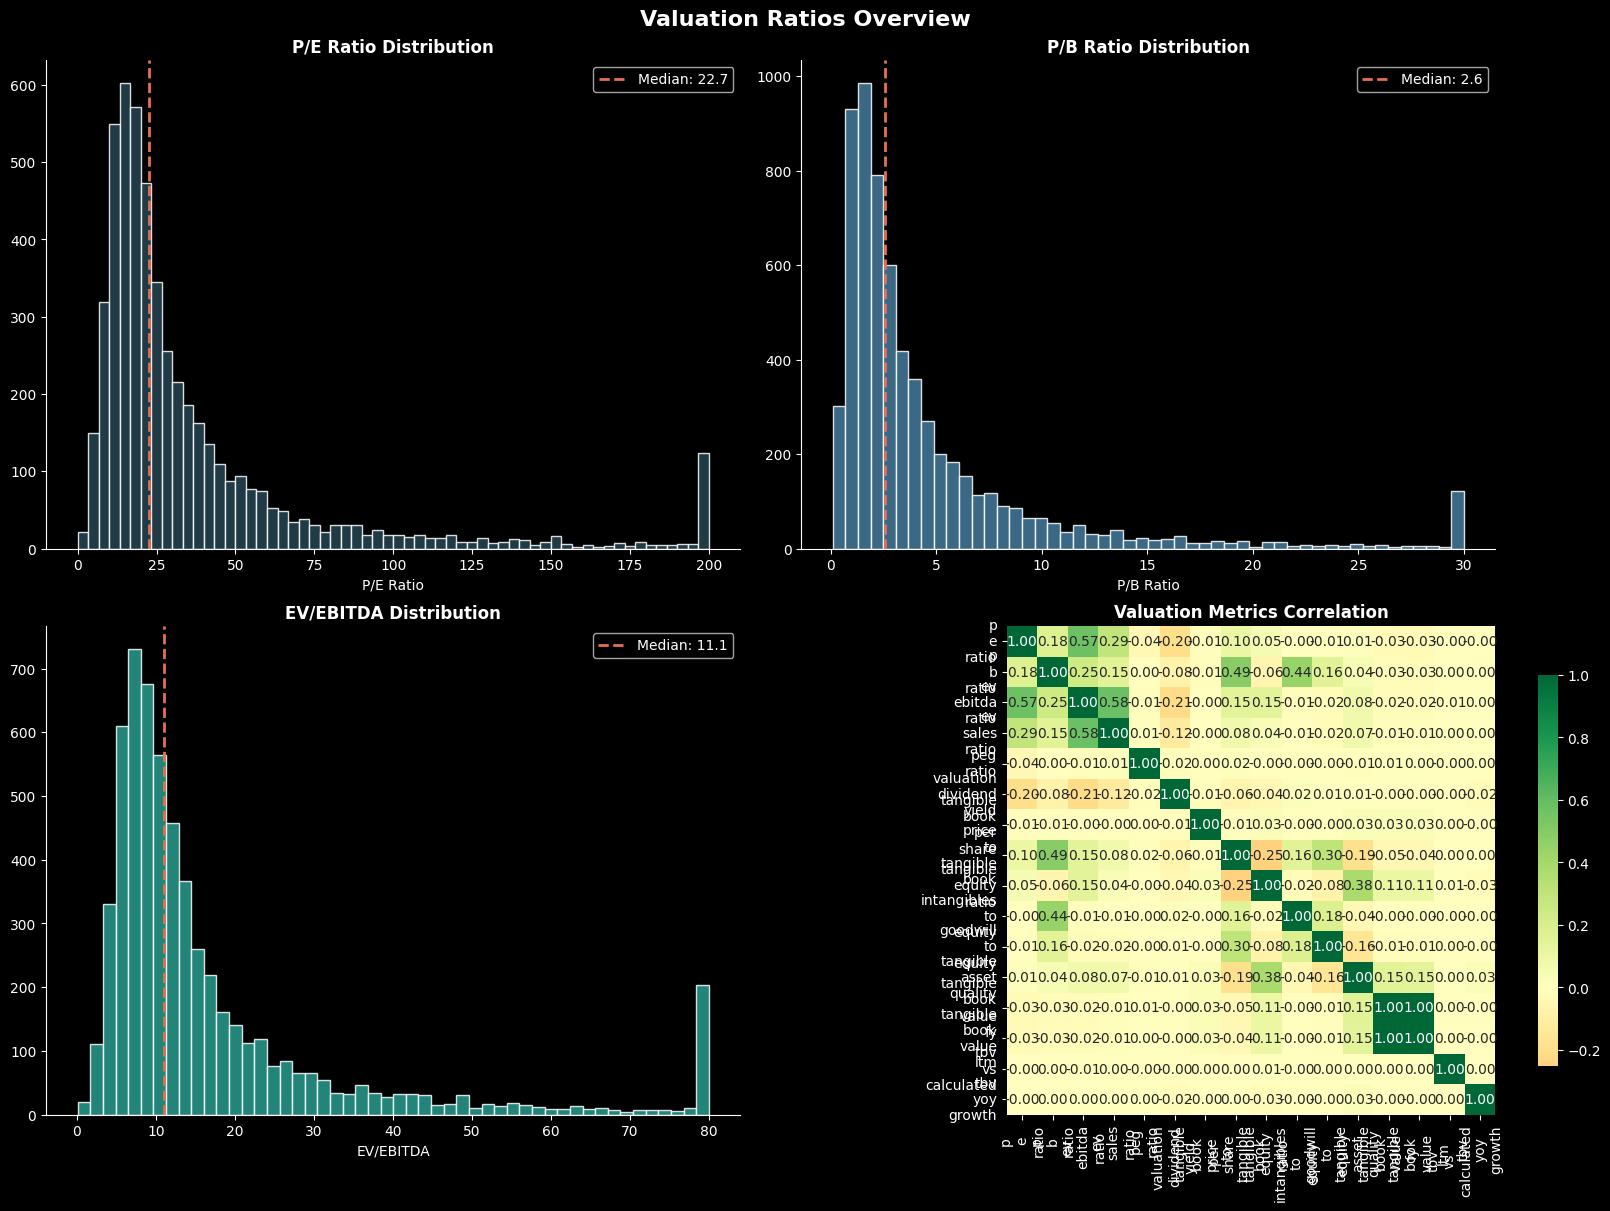

In [10]:
val_cols = [c for c in FEATURE_CATEGORIES.get("Valuation Ratios", []) if c in df.columns]
if len(val_cols) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    fig.suptitle("Valuation Ratios Overview", fontsize=16, fontweight="bold")

    # P/E Distribution
    ax = axes[0, 0]
    pe_col = next((c for c in ["p_e_ratio"] if c in df.columns), None)
    if pe_col:
        pe_data = df[pe_col].dropna().clip(-50, 200)
        ax.hist(pe_data, bins=60, color=COLORS["primary"], alpha=0.85, edgecolor="white")
        ax.axvline(pe_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {pe_data.median():.1f}")
        ax.set_title("P/E Ratio Distribution", fontweight="bold")
        ax.set_xlabel("P/E Ratio")
        ax.legend()

    # P/B Distribution
    ax = axes[0, 1]
    pb_col = next((c for c in ["p_b_ratio"] if c in df.columns), None)
    if pb_col:
        pb_data = df[pb_col].dropna().clip(0, 30)
        ax.hist(pb_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
        ax.axvline(pb_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {pb_data.median():.1f}")
        ax.set_title("P/B Ratio Distribution", fontweight="bold")
        ax.set_xlabel("P/B Ratio")
        ax.legend()

    # EV/EBITDA Distribution
    ax = axes[1, 0]
    ev_col = next((c for c in ["ev_ebitda_ratio"] if c in df.columns), None)
    if ev_col:
        ev_data = df[ev_col].dropna().clip(-10, 80)
        ax.hist(ev_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
        ax.axvline(ev_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {ev_data.median():.1f}")
        ax.set_title("EV/EBITDA Distribution", fontweight="bold")
        ax.set_xlabel("EV/EBITDA")
        ax.legend()

    # Valuation correlation heatmap
    ax = axes[1, 1]
    val_data = df[val_cols].dropna(thresh=len(val_cols) // 2)
    if len(val_data) > 10:
        corr = val_data.corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                    ax=ax, cbar_kws={"shrink": 0.8}, square=True,
                    xticklabels=[c.replace("_", "\n") for c in corr.columns],
                    yticklabels=[c.replace("_", "\n") for c in corr.columns])
        ax.set_title("Valuation Metrics Correlation", fontweight="bold")

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 5. Profitability & Margins Analysis

C:\Users\markm\AppData\Local\Temp\ipykernel_10900\504397710.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("_", "\n") for c in margin_cols], rotation=45, ha="right", fontsize=8)


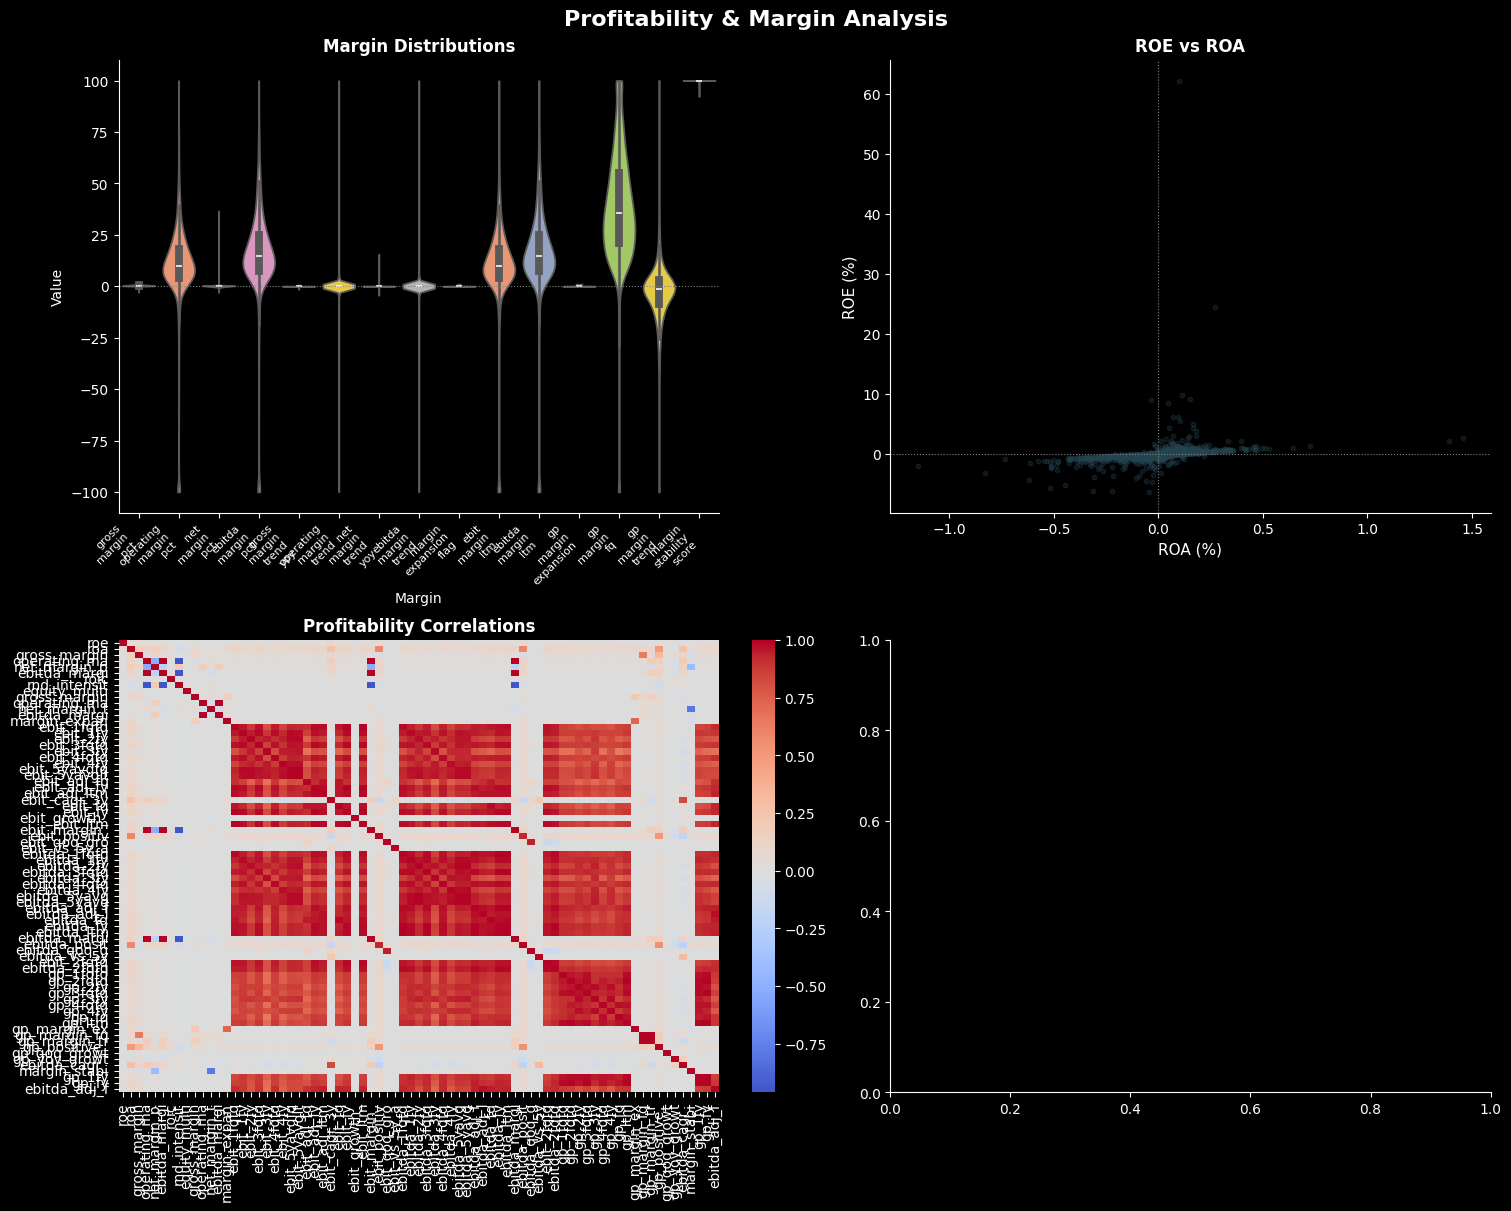

In [11]:
prof_cols = [c for c in FEATURE_CATEGORIES.get("Profitability", []) if c in df.columns]
margin_cols = [c for c in prof_cols if "margin" in c.lower()]
if margin_cols:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)
    fig.suptitle("Profitability & Margin Analysis", fontsize=16, fontweight="bold")

    # Margin distributions (violin)
    ax = axes[0, 0]
    margin_data = df[margin_cols].melt(var_name="Margin", value_name="Value")
    margin_data["Value"] = margin_data["Value"].clip(-100, 100)
    sns.violinplot(data=margin_data, x="Margin", y="Value", ax=ax, inner="box",
                   palette="Set2", cut=0)
    ax.set_xticklabels([c.replace("_", "\n") for c in margin_cols], rotation=45, ha="right", fontsize=8)
    ax.set_title("Margin Distributions", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)

    # ROE vs ROA scatter
    ax = axes[0, 1]
    roe_col = next((c for c in ["roe"] if c in df.columns), None)
    roa_col = next((c for c in ["roa"] if c in df.columns), None)
    if roe_col and roa_col:
        valid = df[[roe_col, roa_col]].dropna()
        valid = valid[(valid[roe_col].between(-100, 200)) & (valid[roa_col].between(-50, 50))]
        ax.scatter(valid[roa_col], valid[roe_col], alpha=0.3, s=10, c=COLORS["primary"])
        ax.set_xlabel("ROA (%)", fontsize=11)
        ax.set_ylabel("ROE (%)", fontsize=11)
        ax.set_title("ROE vs ROA", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    # Profitability correlation
    ax = axes[1, 0]
    if len(prof_cols) >= 3:
        prof_data = df[prof_cols].dropna(thresh=len(prof_cols) // 2)
        if len(prof_data) > 10:
            corr = prof_data.corr()
            sns.heatmap(corr, annot=False, fmt=".1f", cmap="coolwarm", center=0, ax=ax,
                        xticklabels=[c[:12] for c in corr.columns],
                        yticklabels=[c[:12] for c in corr.columns], square=False)
            ax.set_title("Profitability Correlations", fontweight="bold")

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 6. Momentum & Technical Analysis

C:\Users\markm\AppData\Local\Temp\ipykernel_10900\828036699.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("price_momentum_", "") for c in price_mom_cols],


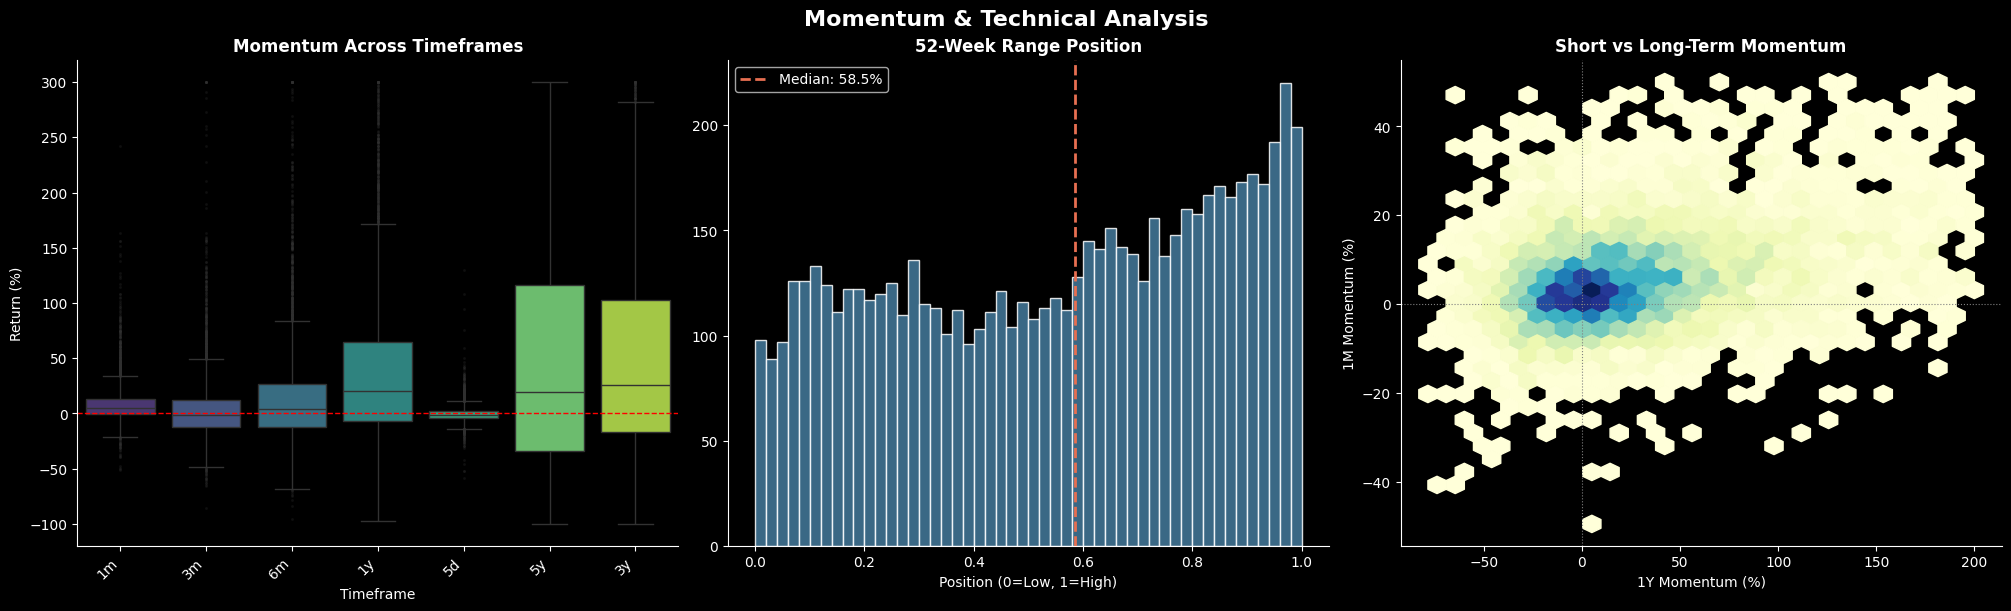

In [12]:
mom_cols = [c for c in FEATURE_CATEGORIES.get("Momentum & Technical", []) if c in df.columns]
price_mom_cols = [c for c in mom_cols if c.startswith("price_momentum")]
if price_mom_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    fig.suptitle("Momentum & Technical Analysis", fontsize=16, fontweight="bold")

    # Momentum ribbon (box plots across timeframes)
    ax = axes[0]
    mom_data = df[price_mom_cols].melt(var_name="Timeframe", value_name="Return")
    mom_data["Return"] = mom_data["Return"].clip(-100, 300)
    sns.boxplot(data=mom_data, x="Timeframe", y="Return", ax=ax, palette="viridis",
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_xticklabels([c.replace("price_momentum_", "") for c in price_mom_cols],
                       rotation=45, ha="right")
    ax.axhline(0, color="red", linestyle="--", lw=1)
    ax.set_title("Momentum Across Timeframes", fontweight="bold")
    ax.set_ylabel("Return (%)")

    # 52-week range position histogram
    ax = axes[1]
    range_col = next((c for c in ["range_52w_position"] if c in df.columns), None)
    if range_col:
        range_data = df[range_col].dropna()
        ax.hist(range_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
        ax.axvline(range_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {range_data.median():.1%}")
        ax.set_title("52-Week Range Position", fontweight="bold")
        ax.set_xlabel("Position (0=Low, 1=High)")
        ax.legend()

    # Short vs long-term momentum scatter
    ax = axes[2]
    short_col = next((c for c in ["price_momentum_1m"] if c in df.columns), None)
    long_col = next((c for c in ["price_momentum_1y"] if c in df.columns), None)
    if short_col and long_col:
        valid = df[[short_col, long_col]].dropna()
        valid = valid[valid[short_col].between(-50, 50) & valid[long_col].between(-80, 200)]
        ax.hexbin(valid[long_col], valid[short_col], gridsize=30, cmap="YlGnBu", mincnt=1)
        ax.set_xlabel("1Y Momentum (%)")
        ax.set_ylabel("1M Momentum (%)")
        ax.set_title("Short vs Long-Term Momentum", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 7. Earnings Quality & EPS Trajectory

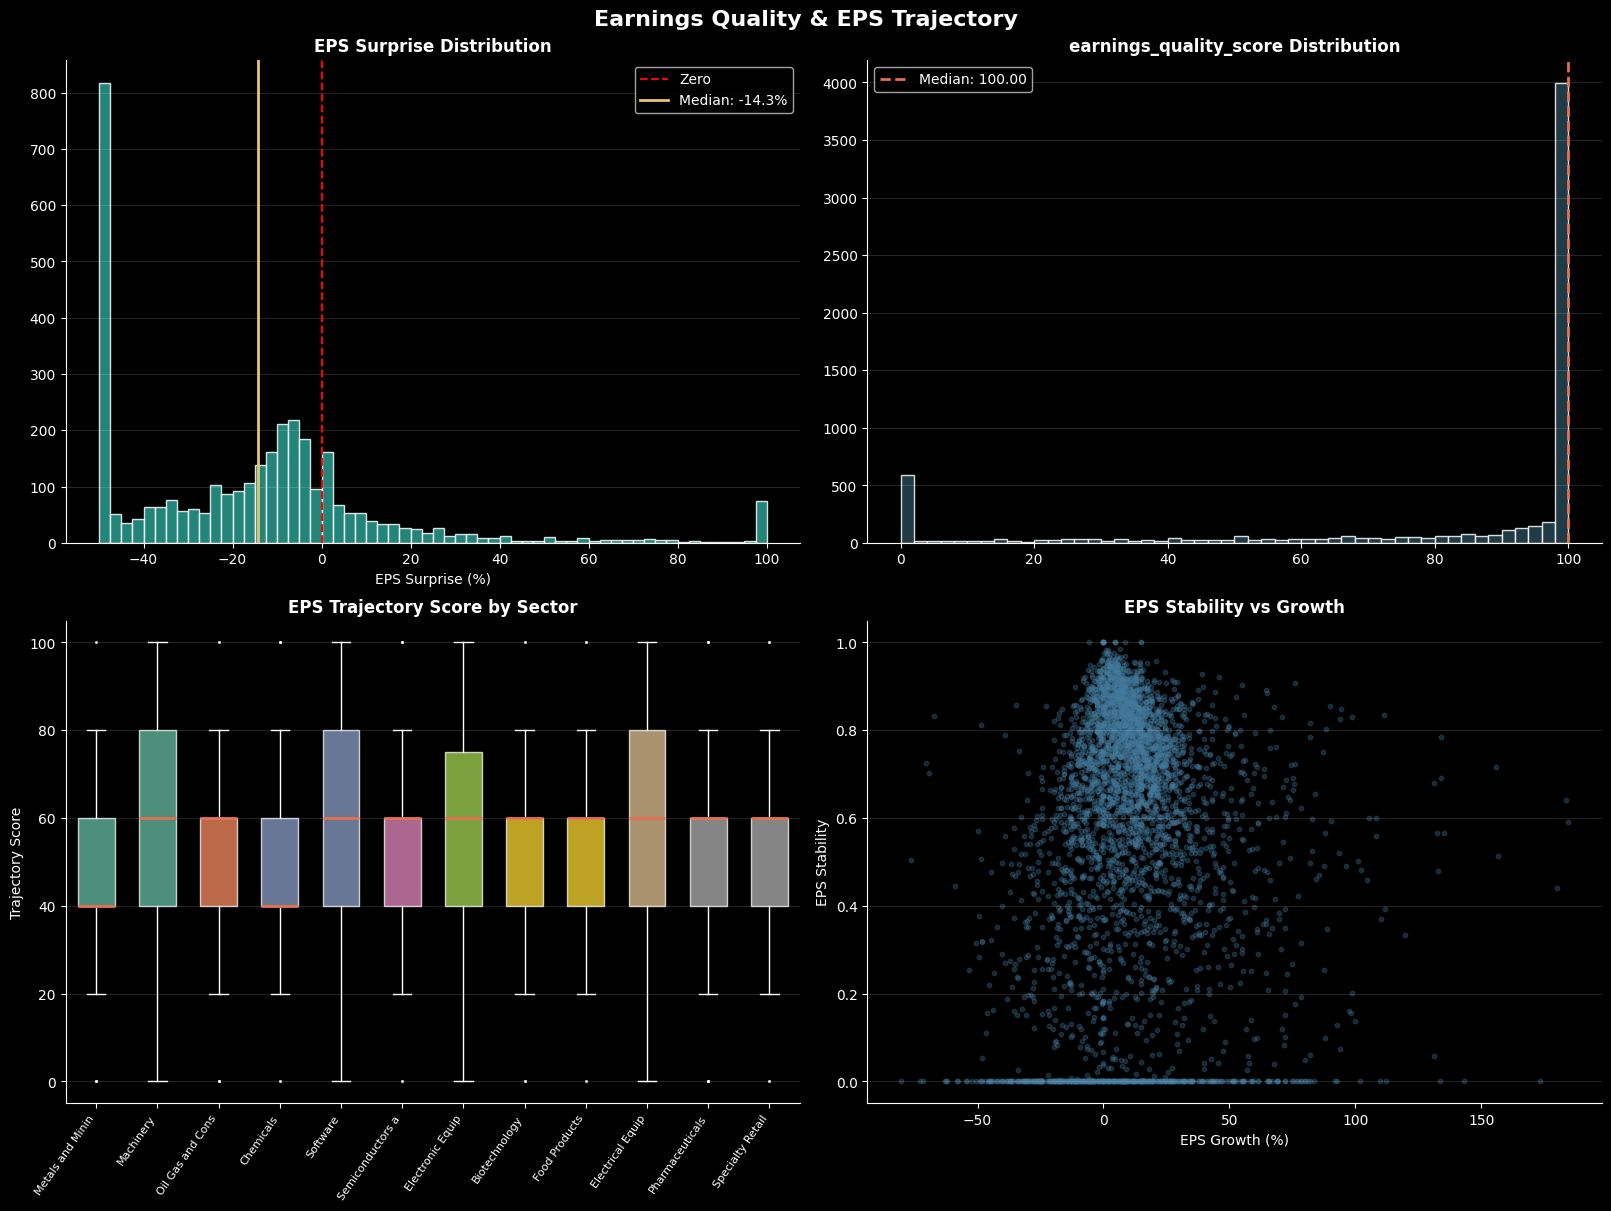

In [13]:
eq_cols = [c for c in FEATURE_CATEGORIES.get("Earnings Quality", []) if c in df.columns]
eps_cols = [c for c in FEATURE_CATEGORIES.get("EPS Trajectory", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Earnings Quality & EPS Trajectory", fontsize=16, fontweight="bold")

# EPS surprise distribution
ax = axes[0, 0]
surprise_col = next((c for c in ["eps_surprise_pct"] if c in df.columns), None)
if surprise_col:
    surprise_data = df[surprise_col].dropna().clip(-50, 100)
    ax.hist(surprise_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero")
    ax.axvline(surprise_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {surprise_data.median():.1f}%")
    ax.set_title("EPS Surprise Distribution", fontweight="bold")
    ax.set_xlabel("EPS Surprise (%)")
    ax.legend()

# Earnings quality score distribution
ax = axes[0, 1]
eq_score = next((c for c in ["earnings_quality_score", "earnings_quality_composite"] if c in df.columns), None)
if eq_score:
    score_data = df[eq_score].dropna()
    ax.hist(score_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(score_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {score_data.median():.2f}")
    ax.set_title(f"{eq_score} Distribution", fontweight="bold")
    ax.legend()

# EPS trajectory score by sector
ax = axes[1, 0]
traj_col = next((c for c in ["eps_trajectory_score"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if traj_col and sector_col:
    sectors = df[sector_col].value_counts().head(12).index
    sector_data = [df.loc[df[sector_col] == s, traj_col].dropna().values for s in sectors]
    bp = ax.boxplot(sector_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.set_title("EPS Trajectory Score by Sector", fontweight="bold")
    ax.set_ylabel("Trajectory Score")

# EPS stability vs growth scatter
ax = axes[1, 1]
stab_col = next((c for c in ["eps_stability"] if c in df.columns), None)
growth_col = next((c for c in ["eps_cagr_5y", "eps_yoy_growth"] if c in df.columns), None)
if stab_col and growth_col:
    valid = df[[stab_col, growth_col]].dropna()
    valid = valid[valid[growth_col].between(-100, 200)]
    ax.scatter(valid[growth_col], valid[stab_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.set_xlabel("EPS Growth (%)")
    ax.set_ylabel("EPS Stability")
    ax.set_title("EPS Stability vs Growth", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 8. Growth Metrics Analysis

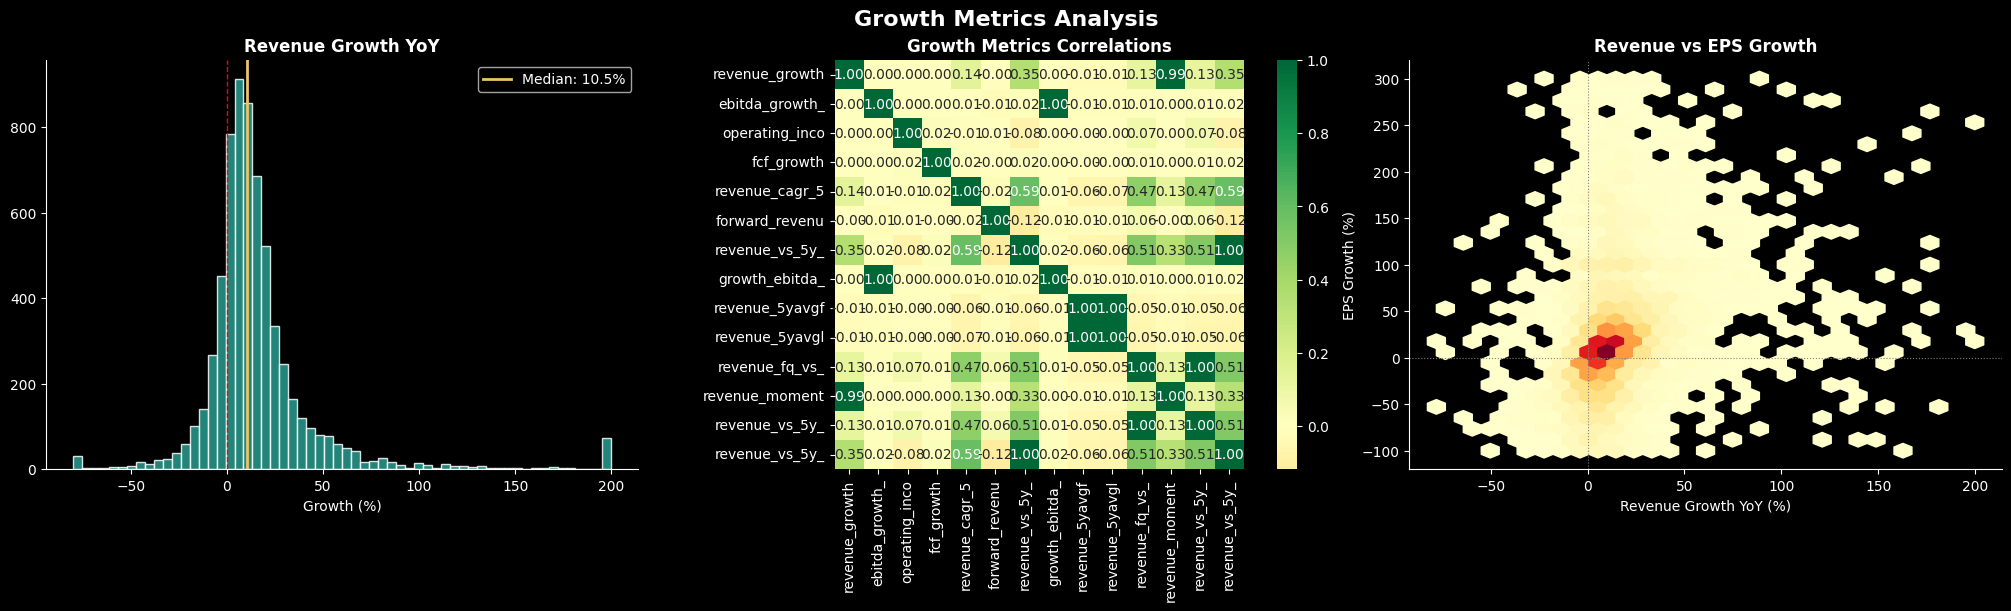

In [14]:
growth_cols = [c for c in FEATURE_CATEGORIES.get("Growth Metrics", []) if c in df.columns]
if growth_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    fig.suptitle("Growth Metrics Analysis", fontsize=16, fontweight="bold")

    # Revenue growth distribution
    ax = axes[0]
    rev_col = next((c for c in ["revenue_growth_yoy"] if c in df.columns), None)
    if rev_col:
        rev_data = df[rev_col].dropna().clip(-80, 200)
        ax.hist(rev_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
        ax.axvline(0, color="red", linestyle="--", lw=1)
        ax.axvline(rev_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
                   label=f"Median: {rev_data.median():.1f}%")
        ax.set_title("Revenue Growth YoY", fontweight="bold")
        ax.set_xlabel("Growth (%)")
        ax.legend()

    # Growth correlation heatmap
    ax = axes[1]
    g_data = df[growth_cols].dropna(thresh=len(growth_cols) // 2)
    if len(g_data) > 10:
        corr = g_data.corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax,
                    xticklabels=[c[:14] for c in corr.columns],
                    yticklabels=[c[:14] for c in corr.columns], square=True)
        ax.set_title("Growth Metrics Correlations", fontweight="bold")

    # Revenue vs EPS growth scatter
    ax = axes[2]
    eps_g = next((c for c in ["eps_yoy_growth", "eps_cagr_5y"] if c in df.columns), None)
    if rev_col and eps_g:
        valid = df[[rev_col, eps_g]].dropna()
        valid = valid[valid[rev_col].between(-80, 200) & valid[eps_g].between(-100, 300)]
        ax.hexbin(valid[rev_col], valid[eps_g], gridsize=30, cmap="YlOrRd", mincnt=1)
        ax.set_xlabel("Revenue Growth YoY (%)")
        ax.set_ylabel("EPS Growth (%)")
        ax.set_title("Revenue vs EPS Growth", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 9. Quality & Risk Assessment

C:\Users\markm\AppData\Local\Temp\ipykernel_10900\2282882155.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


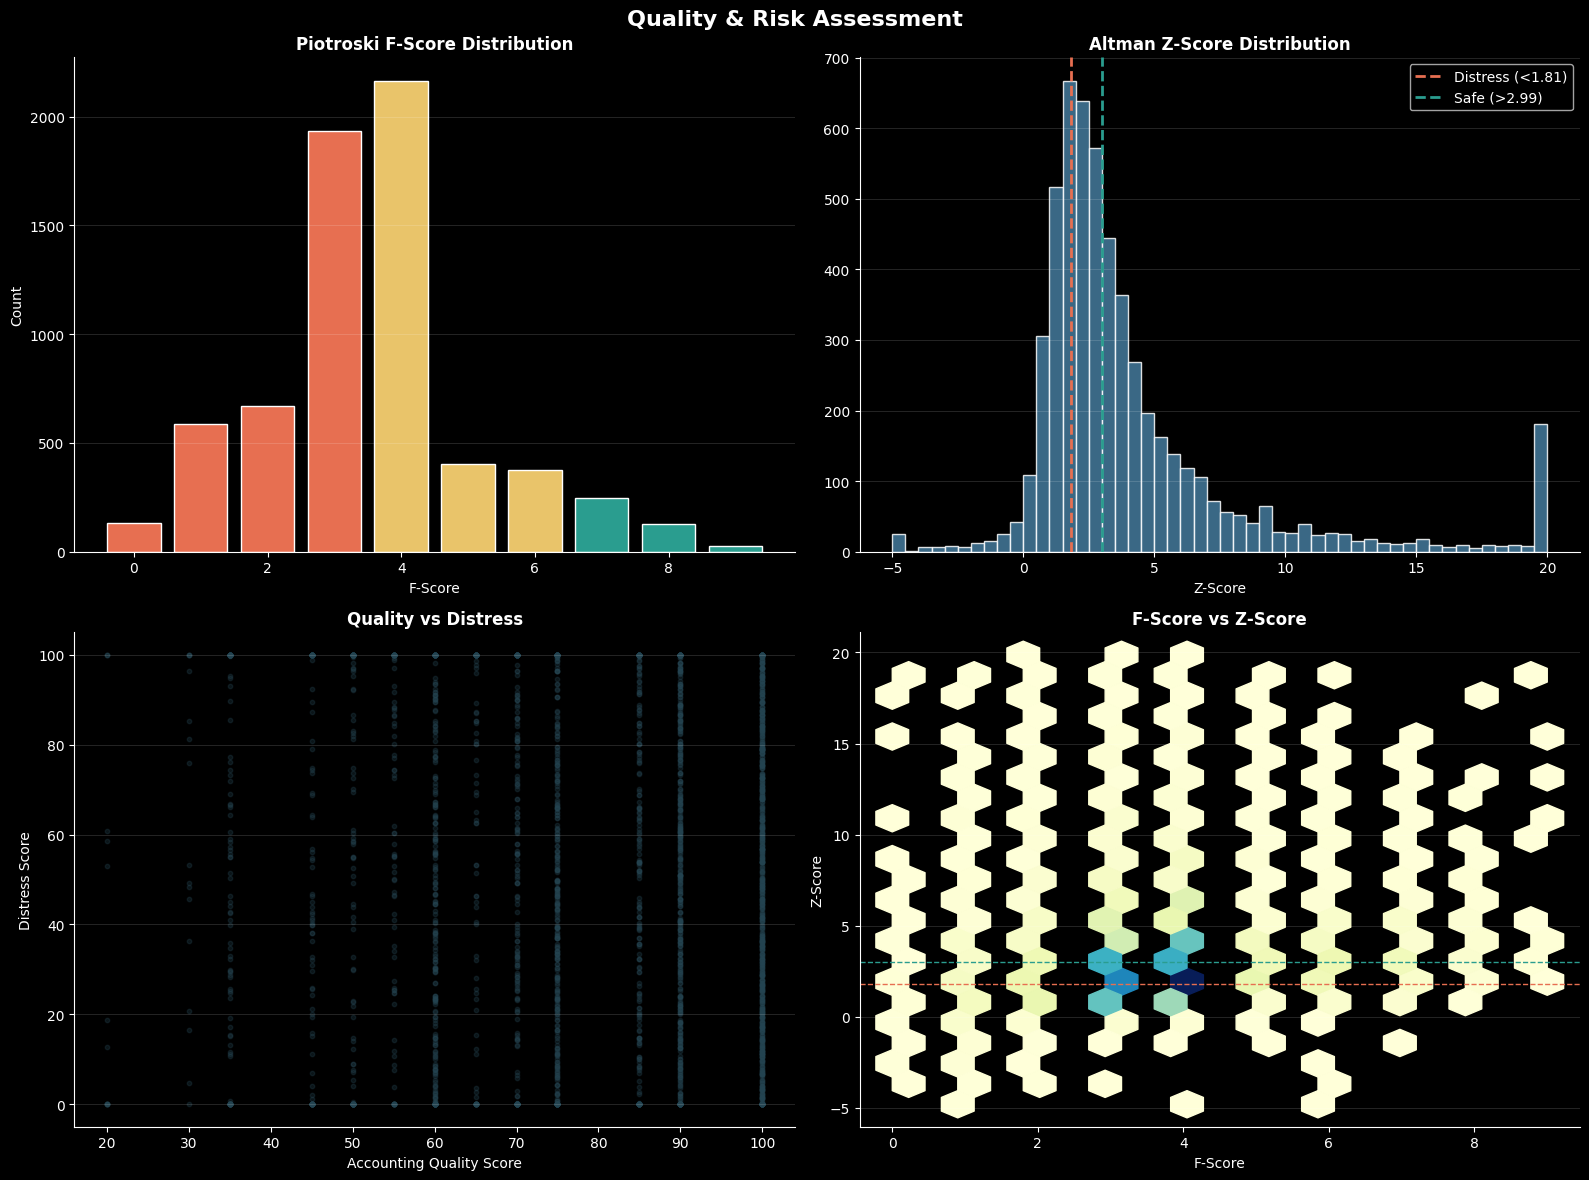

In [15]:
qr_cols = [c for c in FEATURE_CATEGORIES.get("Quality & Risk", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Quality & Risk Assessment", fontsize=16, fontweight="bold")

# Piotroski F-Score distribution
ax = axes[0, 0]
fscore_col = next((c for c in ["piotroski_f_score"] if c in df.columns), None)
if fscore_col:
    fscore_data = df[fscore_col].dropna()
    counts = fscore_data.value_counts().sort_index()
    bar_colors = [COLORS["danger"] if v <= 3 else COLORS["accent"] if v <= 6
    else COLORS["secondary"] for v in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title("Piotroski F-Score Distribution", fontweight="bold")
    ax.set_xlabel("F-Score")
    ax.set_ylabel("Count")

# Altman Z-Score distribution
ax = axes[0, 1]
zscore_col = next((c for c in ["altman_z_score", "altman_z_score_fy"] if c in df.columns), None)
if zscore_col:
    zscore_data = df[zscore_col].dropna().clip(-5, 20)
    ax.hist(zscore_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(1.81, color=COLORS["danger"], linestyle="--", lw=2, label="Distress (<1.81)")
    ax.axvline(2.99, color=COLORS["secondary"], linestyle="--", lw=2, label="Safe (>2.99)")
    ax.set_title("Altman Z-Score Distribution", fontweight="bold")
    ax.set_xlabel("Z-Score")
    ax.legend()

# Quality score vs Risk scatter
ax = axes[1, 0]
aq_col = next((c for c in ["accounting_quality_score"] if c in df.columns), None)
distress_col = next((c for c in ["combined_distress_score"] if c in df.columns), None)
if aq_col and distress_col:
    valid = df[[aq_col, distress_col]].dropna()
    ax.scatter(valid[aq_col], valid[distress_col], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("Accounting Quality Score")
    ax.set_ylabel("Distress Score")
    ax.set_title("Quality vs Distress", fontweight="bold")

# F-Score vs Z-Score joint distribution
ax = axes[1, 1]
if fscore_col and zscore_col:
    valid = df[[fscore_col, zscore_col]].dropna()
    valid = valid[valid[zscore_col].between(-5, 20)]
    ax.hexbin(valid[fscore_col], valid[zscore_col], gridsize=20, cmap="YlGnBu", mincnt=1)
    ax.set_xlabel("F-Score")
    ax.set_ylabel("Z-Score")
    ax.set_title("F-Score vs Z-Score", fontweight="bold")
    ax.axhline(1.81, color=COLORS["danger"], linestyle="--", lw=1)
    ax.axhline(2.99, color=COLORS["secondary"], linestyle="--", lw=1)

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Leverage & Liquidity Analysis

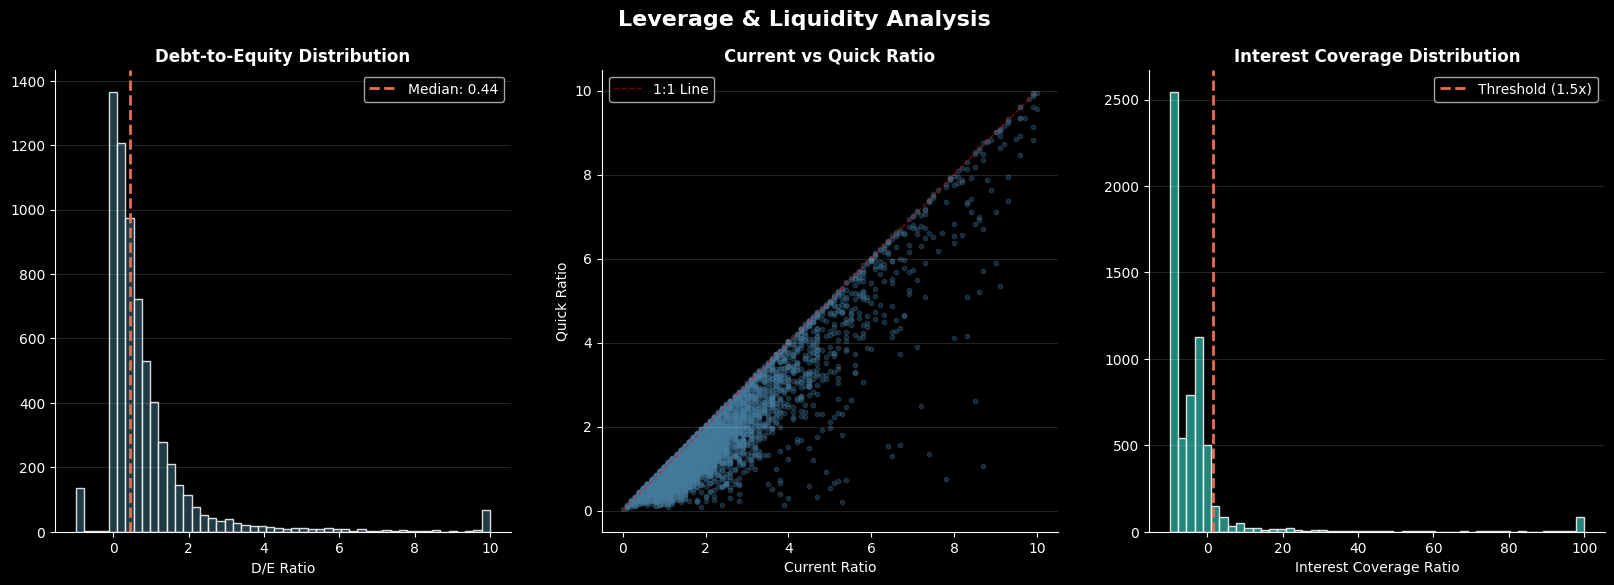

In [16]:
lev_cols = [c for c in FEATURE_CATEGORIES.get("Leverage & Liquidity", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Leverage & Liquidity Analysis", fontsize=16, fontweight="bold")

# Debt-to-Equity distribution
ax = axes[0]
dte_col = next((c for c in ["debt_to_equity"] if c in df.columns), None)
if dte_col:
    dte_data = df[dte_col].dropna().clip(-1, 10)
    ax.hist(dte_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(dte_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {dte_data.median():.2f}")
    ax.set_title("Debt-to-Equity Distribution", fontweight="bold")
    ax.set_xlabel("D/E Ratio")
    ax.legend()

# Current Ratio vs Quick Ratio
ax = axes[1]
cr_col = next((c for c in ["current_ratio"] if c in df.columns), None)
qr_col = next((c for c in ["quick_ratio"] if c in df.columns), None)
if cr_col and qr_col:
    valid = df[[cr_col, qr_col]].dropna()
    valid = valid[(valid[cr_col].between(0, 10)) & (valid[qr_col].between(0, 10))]
    ax.scatter(valid[cr_col], valid[qr_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.plot([0, 10], [0, 10], "r--", lw=1, alpha=0.5, label="1:1 Line")
    ax.set_xlabel("Current Ratio")
    ax.set_ylabel("Quick Ratio")
    ax.set_title("Current vs Quick Ratio", fontweight="bold")
    ax.legend()

# Interest coverage distribution
ax = axes[2]
ic_col = next((c for c in ["interest_coverage"] if c in df.columns), None)
if ic_col:
    ic_data = df[ic_col].dropna().clip(-10, 100)
    ax.hist(ic_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(1.5, color=COLORS["danger"], linestyle="--", lw=2, label="Threshold (1.5x)")
    ax.set_title("Interest Coverage Distribution", fontweight="bold")
    ax.set_xlabel("Interest Coverage Ratio")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 11. Analyst Sentiment & Price Targets

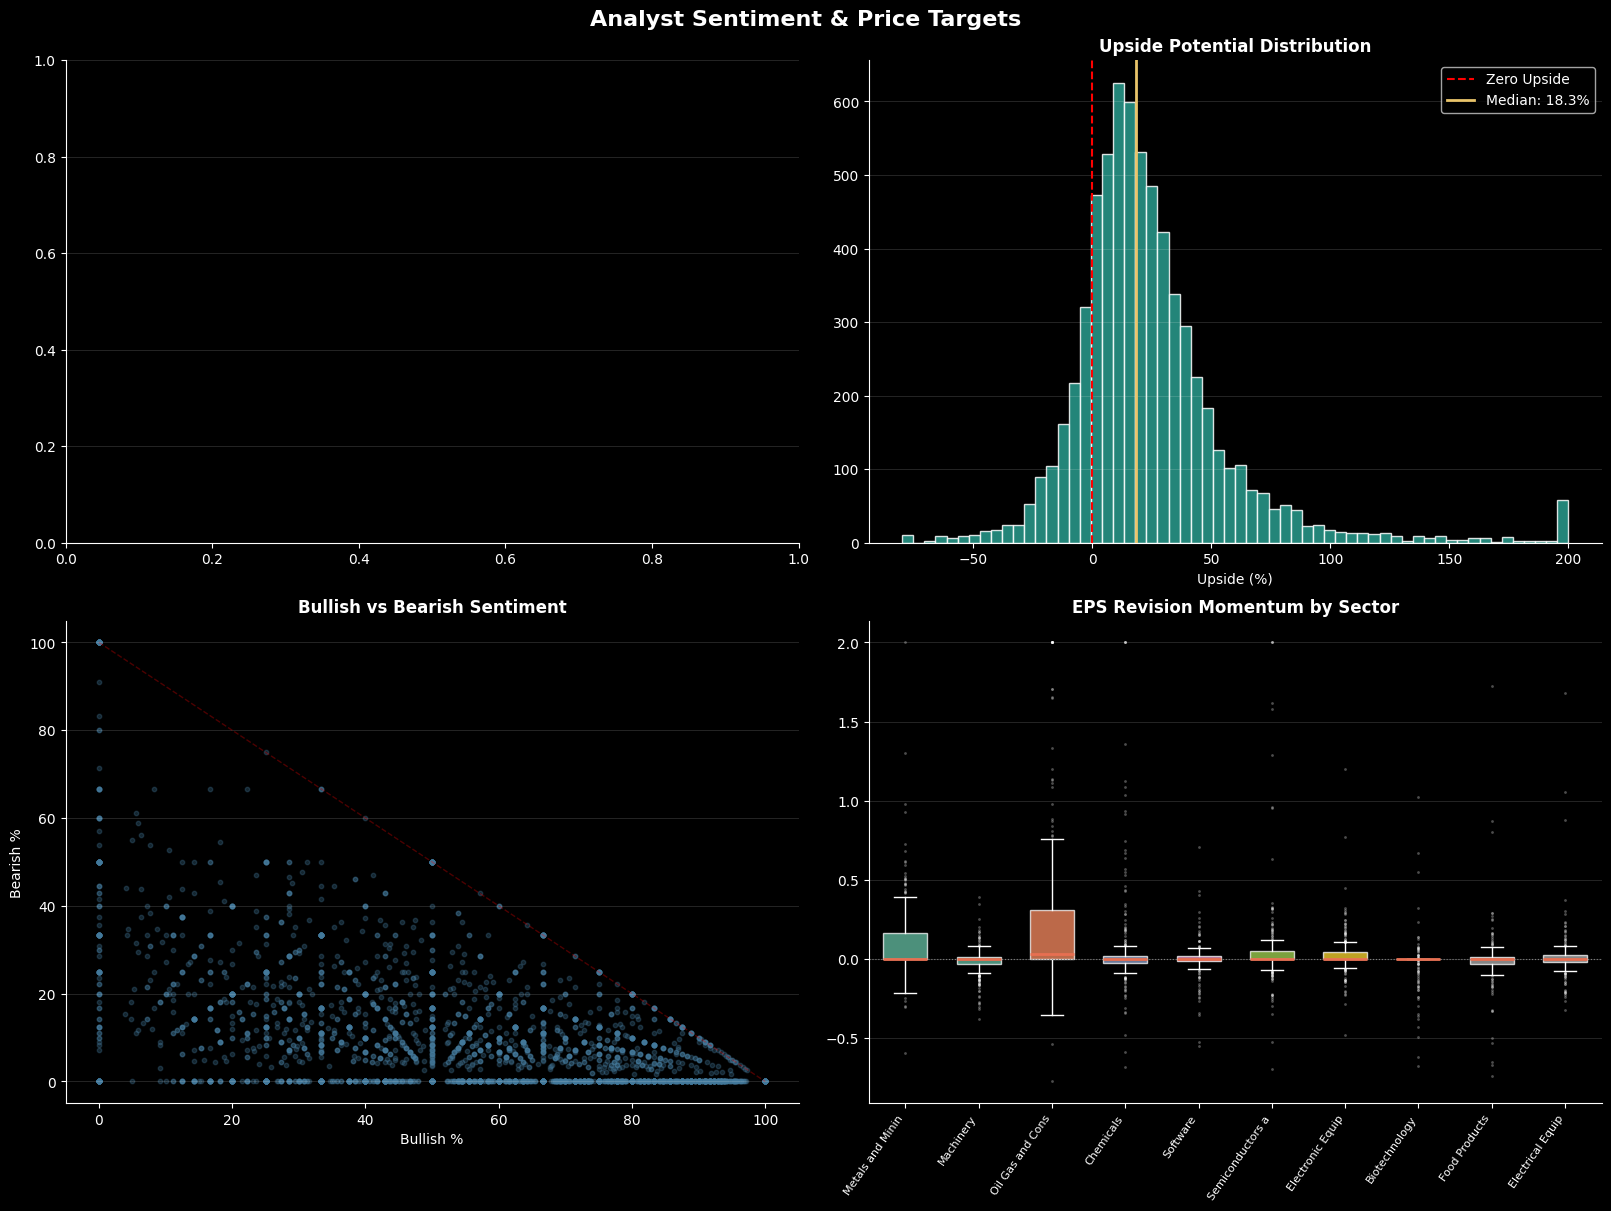

In [17]:
sent_cols = [c for c in FEATURE_CATEGORIES.get("Analyst Sentiment", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Analyst Sentiment & Price Targets", fontsize=16, fontweight="bold")

# Analyst rating distribution
ax = axes[0, 0]
rating_col = next((c for c in ["analyst_rating"] if c in df.columns), None)
if rating_col:
    rating_data = df[rating_col].dropna()
    ax.hist(rating_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(rating_data.mean(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Mean: {rating_data.mean():.1f}")
    ax.set_title("Analyst Rating Distribution", fontweight="bold")
    ax.set_xlabel("Rating")
    ax.legend()

# Upside potential distribution
ax = axes[0, 1]
upside_col = next((c for c in ["upside_potential"] if c in df.columns), None)
if upside_col:
    upside_data = df[upside_col].dropna().clip(-80, 200)
    ax.hist(upside_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero Upside")
    ax.axvline(upside_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {upside_data.median():.1f}%")
    ax.set_title("Upside Potential Distribution", fontweight="bold")
    ax.set_xlabel("Upside (%)")
    ax.legend()

# Bullish vs Bearish sentiment
ax = axes[1, 0]
bull_col = next((c for c in ["analyst_bullish_pct"] if c in df.columns), None)
bear_col = next((c for c in ["analyst_bearish_pct"] if c in df.columns), None)
if bull_col and bear_col:
    valid = df[[bull_col, bear_col]].dropna()
    ax.scatter(valid[bull_col], valid[bear_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.set_xlabel("Bullish %")
    ax.set_ylabel("Bearish %")
    ax.set_title("Bullish vs Bearish Sentiment", fontweight="bold")
    ax.plot([0, 100], [100, 0], "r--", lw=1, alpha=0.3)

# EPS revision momentum by sector
ax = axes[1, 1]
rev_mom_col = next((c for c in ["eps_revision_momentum"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if rev_mom_col and sector_col:
    sectors = df[sector_col].value_counts().head(10).index
    rev_data = [df.loc[df[sector_col] == s, rev_mom_col].dropna().clip(-2, 2).values for s in sectors]
    bp = ax.boxplot(rev_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.set_title("EPS Revision Momentum by Sector", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 12. Cash Flow Analysis

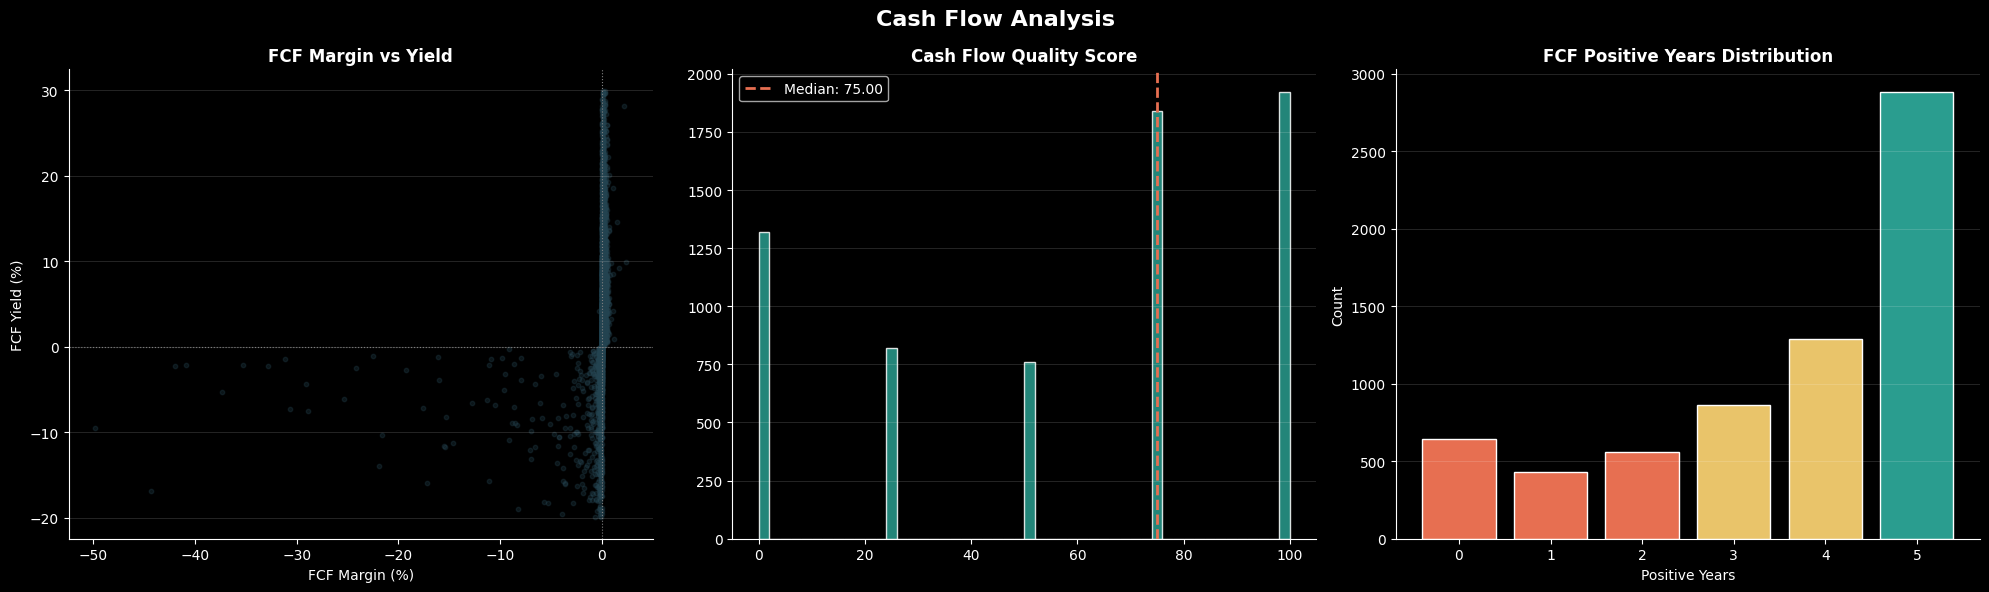

In [18]:
cf_cols = [c for c in FEATURE_CATEGORIES.get("Cash Flow", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Cash Flow Analysis", fontsize=16, fontweight="bold")

# FCF margin vs FCF yield scatter
ax = axes[0]
fcf_m = next((c for c in ["fcf_margin"] if c in df.columns), None)
fcf_y = next((c for c in ["fcf_yield"] if c in df.columns), None)
if fcf_m and fcf_y:
    valid = df[[fcf_m, fcf_y]].dropna()
    valid = valid[valid[fcf_m].between(-50, 60) & valid[fcf_y].between(-20, 30)]
    ax.scatter(valid[fcf_m], valid[fcf_y], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("FCF Margin (%)")
    ax.set_ylabel("FCF Yield (%)")
    ax.set_title("FCF Margin vs Yield", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.axvline(0, color="grey", linestyle=":", lw=0.8)

# Cash flow quality score
ax = axes[1]
cfq_col = next((c for c in ["cash_flow_quality_score"] if c in df.columns), None)
if cfq_col:
    cfq_data = df[cfq_col].dropna()
    ax.hist(cfq_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(cfq_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {cfq_data.median():.2f}")
    ax.set_title("Cash Flow Quality Score", fontweight="bold")
    ax.legend()

# FCF positive years distribution
ax = axes[2]
fcf_pos = next((c for c in ["fcf_positive_years"] if c in df.columns), None)
if fcf_pos:
    pos_data = df[fcf_pos].dropna()
    counts = pos_data.value_counts().sort_index()
    bar_colors = [COLORS["danger"] if v <= 2 else COLORS["accent"] if v <= 4
    else COLORS["secondary"] for v in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title("FCF Positive Years Distribution", fontweight="bold")
    ax.set_xlabel("Positive Years")
    ax.set_ylabel("Count")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Dividend Reliability Analysis

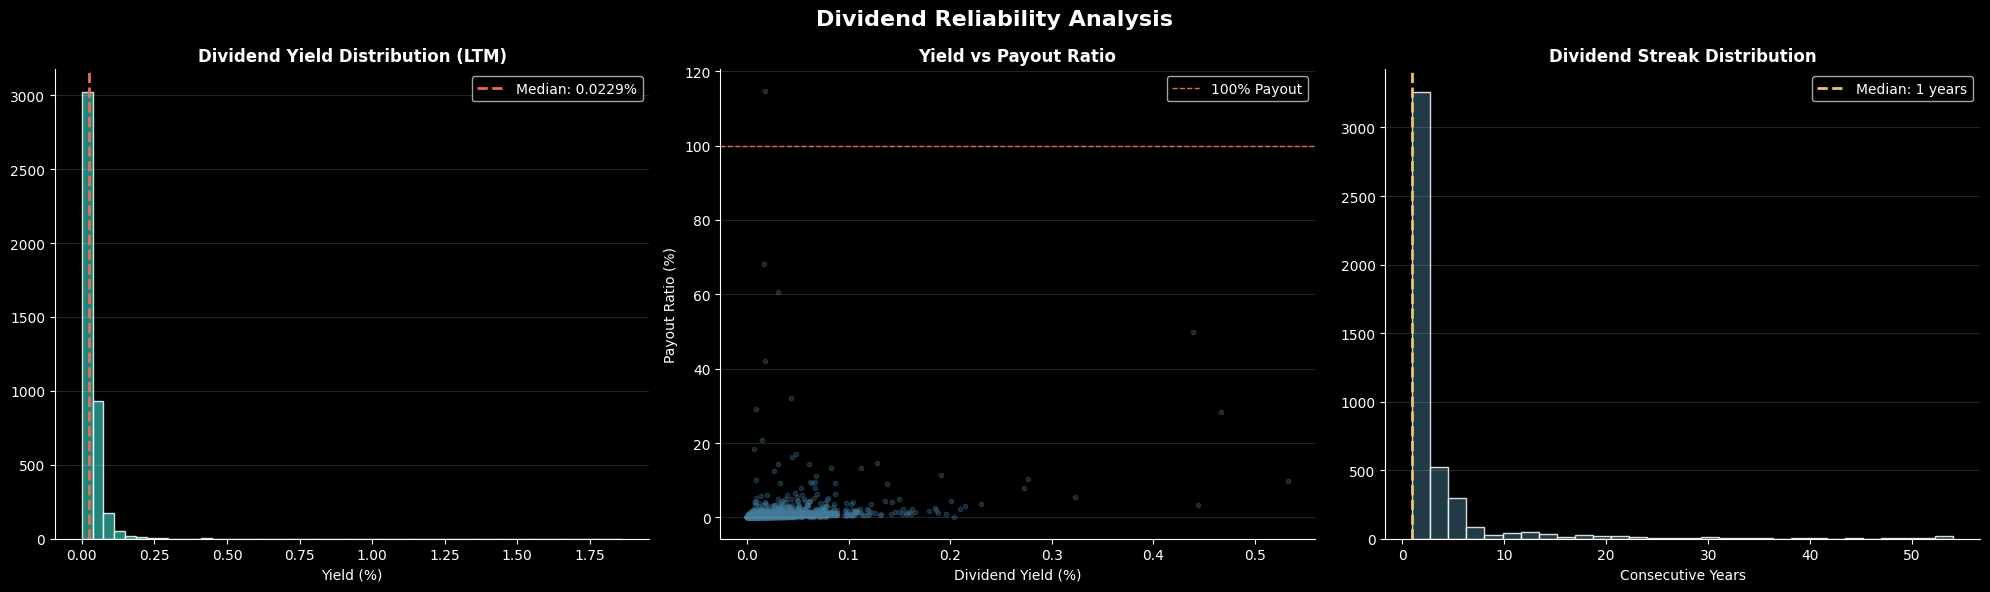

In [19]:
div_cols = [c for c in FEATURE_CATEGORIES.get("Dividend Reliability", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Dividend Reliability Analysis", fontsize=16, fontweight="bold")

# Dividend yield distribution
ax = axes[0]
dy_col = next((c for c in ["dividend_yield_ltm"] if c in df.columns), None)
if dy_col:
    dy_data = df[dy_col].dropna()
    ax.hist(dy_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(dy_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {dy_data.median():.4f}%")
    ax.set_title("Dividend Yield Distribution (LTM)", fontweight="bold")
    ax.set_xlabel("Yield (%)")
    ax.legend()

# Dividend yield vs payout ratio
ax = axes[1]
payout_col = next((c for c in ["dividend_payout_ratio"] if c in df.columns), None)
if dy_col and payout_col:
    valid = df[[dy_col, payout_col]].dropna()
    valid = valid[(valid[dy_col] > 0) & valid[payout_col].between(0, 200)]
    ax.scatter(valid[dy_col], valid[payout_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.axhline(100, color=COLORS["danger"], linestyle="--", lw=1, label="100% Payout")
    ax.set_xlabel("Dividend Yield (%)")
    ax.set_ylabel("Payout Ratio (%)")
    ax.set_title("Yield vs Payout Ratio", fontweight="bold")
    ax.legend()

# Dividend streak distribution
ax = axes[2]
streak_col = next((c for c in ["dividend_streak"] if c in df.columns), None)
if streak_col:
    streak_data = df[streak_col].dropna()
    streak_data = streak_data[streak_data > 0]
    ax.hist(streak_data, bins=30, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(streak_data.median(), color=COLORS["accent"], linestyle="--", lw=2,
               label=f"Median: {streak_data.median():.0f} years")
    ax.set_title("Dividend Streak Distribution", fontweight="bold")
    ax.set_xlabel("Consecutive Years")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 14. Volatility Surface Analysis (Enhancement 2+3)

C:\Users\markm\AppData\Local\Temp\ipykernel_10900\1481445140.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("volatility_", "") for c in vol_term_cols])


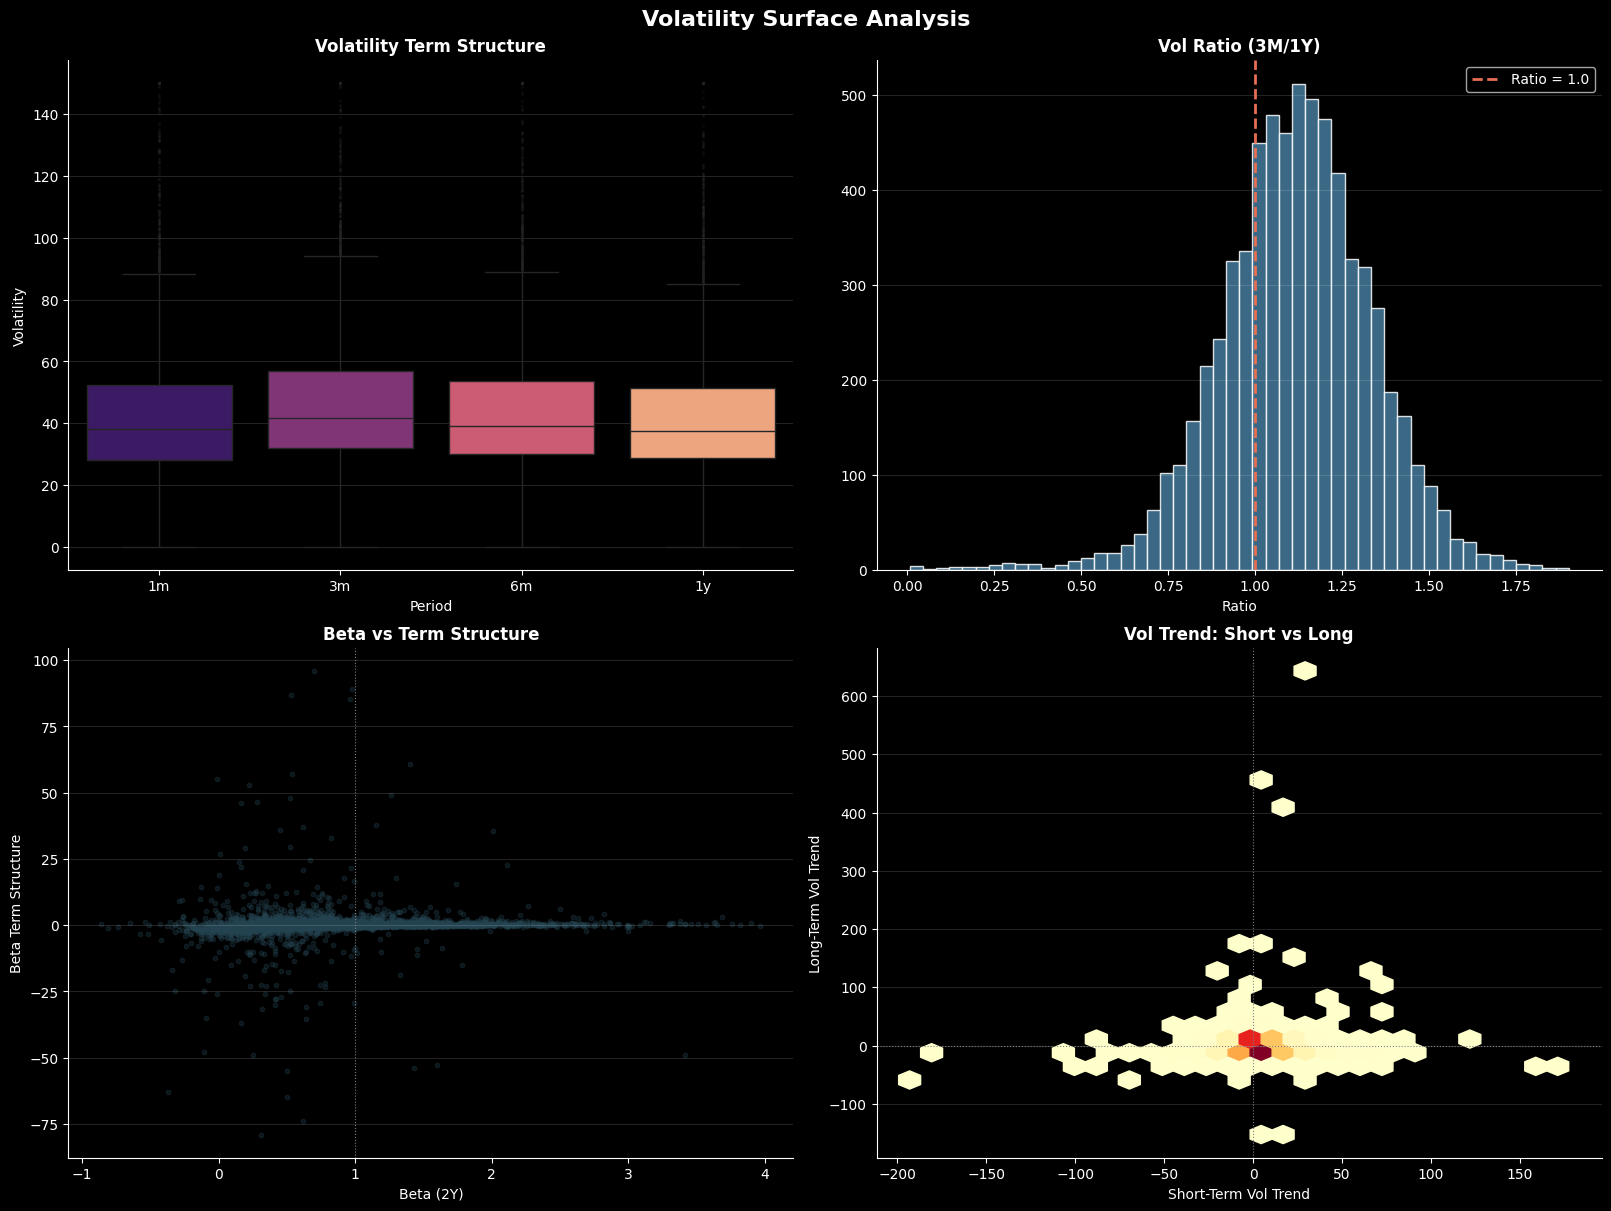

In [20]:
vol_cols = [c for c in FEATURE_CATEGORIES.get("Volatility Surface", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Volatility Surface Analysis", fontsize=16, fontweight="bold")

# Volatility term structure (box plots)
ax = axes[0, 0]
vol_term_cols = [c for c in ["volatility_1m", "volatility_3m", "volatility_6m", "volatility_1y"]
                 if c in df.columns]
if vol_term_cols:
    vol_data = df[vol_term_cols].melt(var_name="Period", value_name="Volatility")
    vol_data["Volatility"] = vol_data["Volatility"].clip(0, 150)
    sns.boxplot(data=vol_data, x="Period", y="Volatility", ax=ax, palette="magma",
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_xticklabels([c.replace("volatility_", "") for c in vol_term_cols])
    ax.set_title("Volatility Term Structure", fontweight="bold")

# Vol ratio 3M/1Y distribution
ax = axes[0, 1]
vr_col = next((c for c in ["vol_ratio_3m_1y"] if c in df.columns), None)
if vr_col:
    vr_data = df[vr_col].dropna().clip(0, 5)
    ax.hist(vr_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(1.0, color=COLORS["danger"], linestyle="--", lw=2, label="Ratio = 1.0")
    ax.set_title("Vol Ratio (3M/1Y)", fontweight="bold")
    ax.set_xlabel("Ratio")
    ax.legend()

# Beta term structure
ax = axes[1, 0]
beta_cols = [c for c in ["beta_2y", "beta_term_structure"] if c in df.columns]
if len(beta_cols) == 2:
    valid = df[beta_cols].dropna()
    valid = valid[valid[beta_cols[0]].between(-1, 4)]
    ax.scatter(valid[beta_cols[0]], valid[beta_cols[1]], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("Beta (2Y)")
    ax.set_ylabel("Beta Term Structure")
    ax.set_title("Beta vs Term Structure", fontweight="bold")
    ax.axvline(1.0, color="grey", linestyle=":", lw=0.8)

# Volatility trend comparison
ax = axes[1, 1]
vt_short = next((c for c in ["volatility_trend_short"] if c in df.columns), None)
vt_long = next((c for c in ["volatility_trend_long"] if c in df.columns), None)
if vt_short and vt_long:
    valid = df[[vt_short, vt_long]].dropna()
    ax.hexbin(valid[vt_short], valid[vt_long], gridsize=30, cmap="YlOrRd", mincnt=1)
    ax.set_xlabel("Short-Term Vol Trend")
    ax.set_ylabel("Long-Term Vol Trend")
    ax.set_title("Vol Trend: Short vs Long", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.axvline(0, color="grey", linestyle=":", lw=0.8)

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 15. Forward Consensus & Estimates (Enhancement 7)

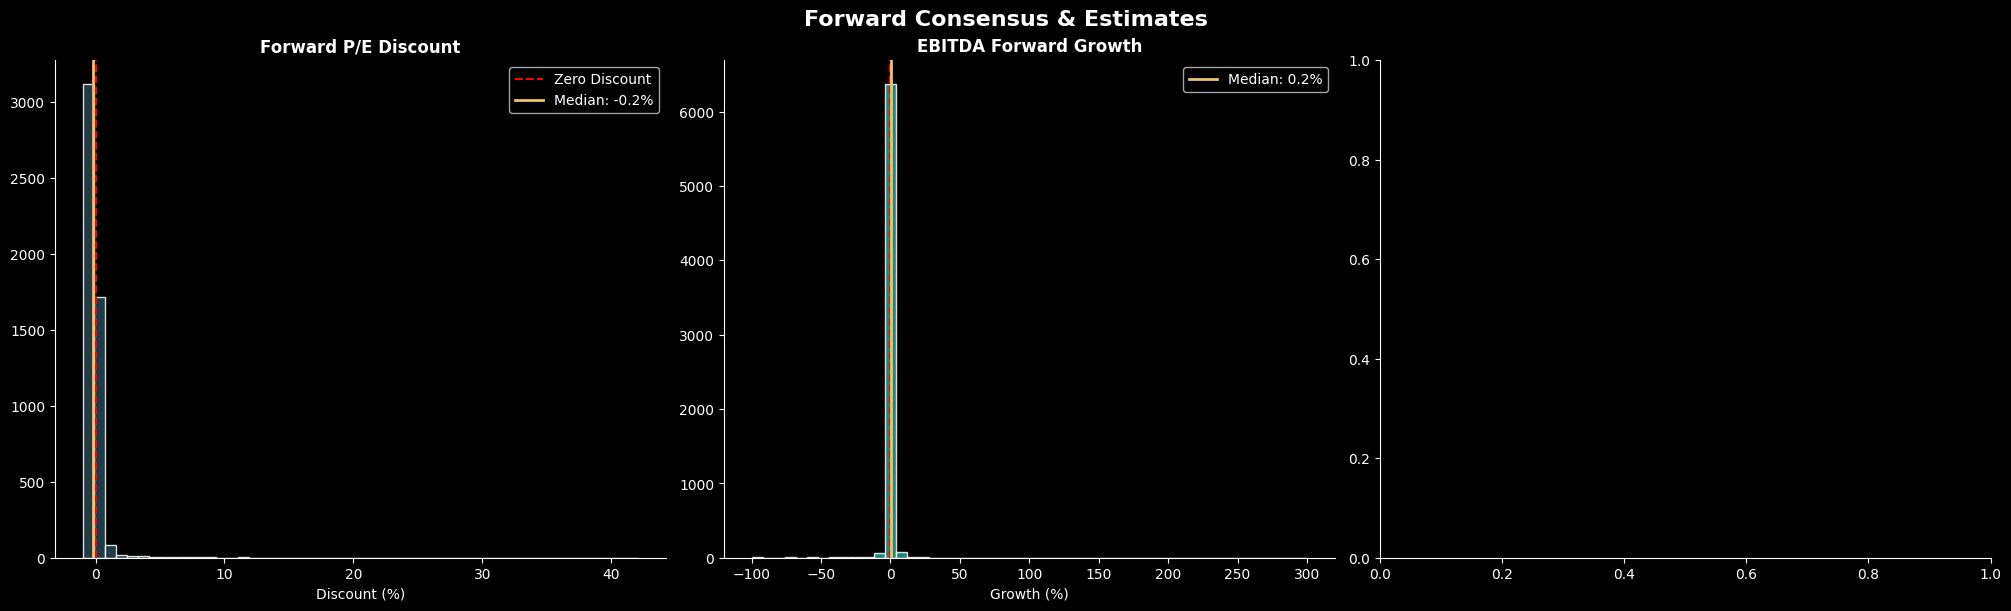

In [21]:
fwd_cols = [c for c in FEATURE_CATEGORIES.get("Forward Consensus", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle("Forward Consensus & Estimates", fontsize=16, fontweight="bold")

# Forward P/E discount distribution
ax = axes[0]
fpe_col = next((c for c in ["pe_forward_discount"] if c in df.columns), None)
if fpe_col:
    fpe_data = df[fpe_col].dropna().clip(-100, 100)
    ax.hist(fpe_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero Discount")
    ax.axvline(fpe_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {fpe_data.median():.1f}%")
    ax.set_title("Forward P/E Discount", fontweight="bold")
    ax.set_xlabel("Discount (%)")
    ax.legend()

# EBITDA forward growth
ax = axes[1]
ebitda_fwd = next((c for c in ["ebitda_forward_growth"] if c in df.columns), None)
if ebitda_fwd:
    ebitda_data = df[ebitda_fwd].dropna().clip(-100, 300)
    ax.hist(ebitda_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.axvline(ebitda_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {ebitda_data.median():.1f}%")
    ax.set_title("EBITDA Forward Growth", fontweight="bold")
    ax.set_xlabel("Growth (%)")
    ax.legend()

# Forward consensus correlation
ax = axes[2]
if len(fwd_cols) >= 3:
    fwd_data = df[fwd_cols].dropna(thresh=len(fwd_cols) // 2)
    if len(fwd_data) > 10:
        corr = fwd_data.corr()
        sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
                    xticklabels=[c[:14] for c in corr.columns],
                    yticklabels=[c[:14] for c in corr.columns], square=True)
        ax.set_title("Forward Consensus Correlations", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
plt.show()

## 16. Enhancement Features: Tax, OpEx, FCF Estimates, Share Dilution

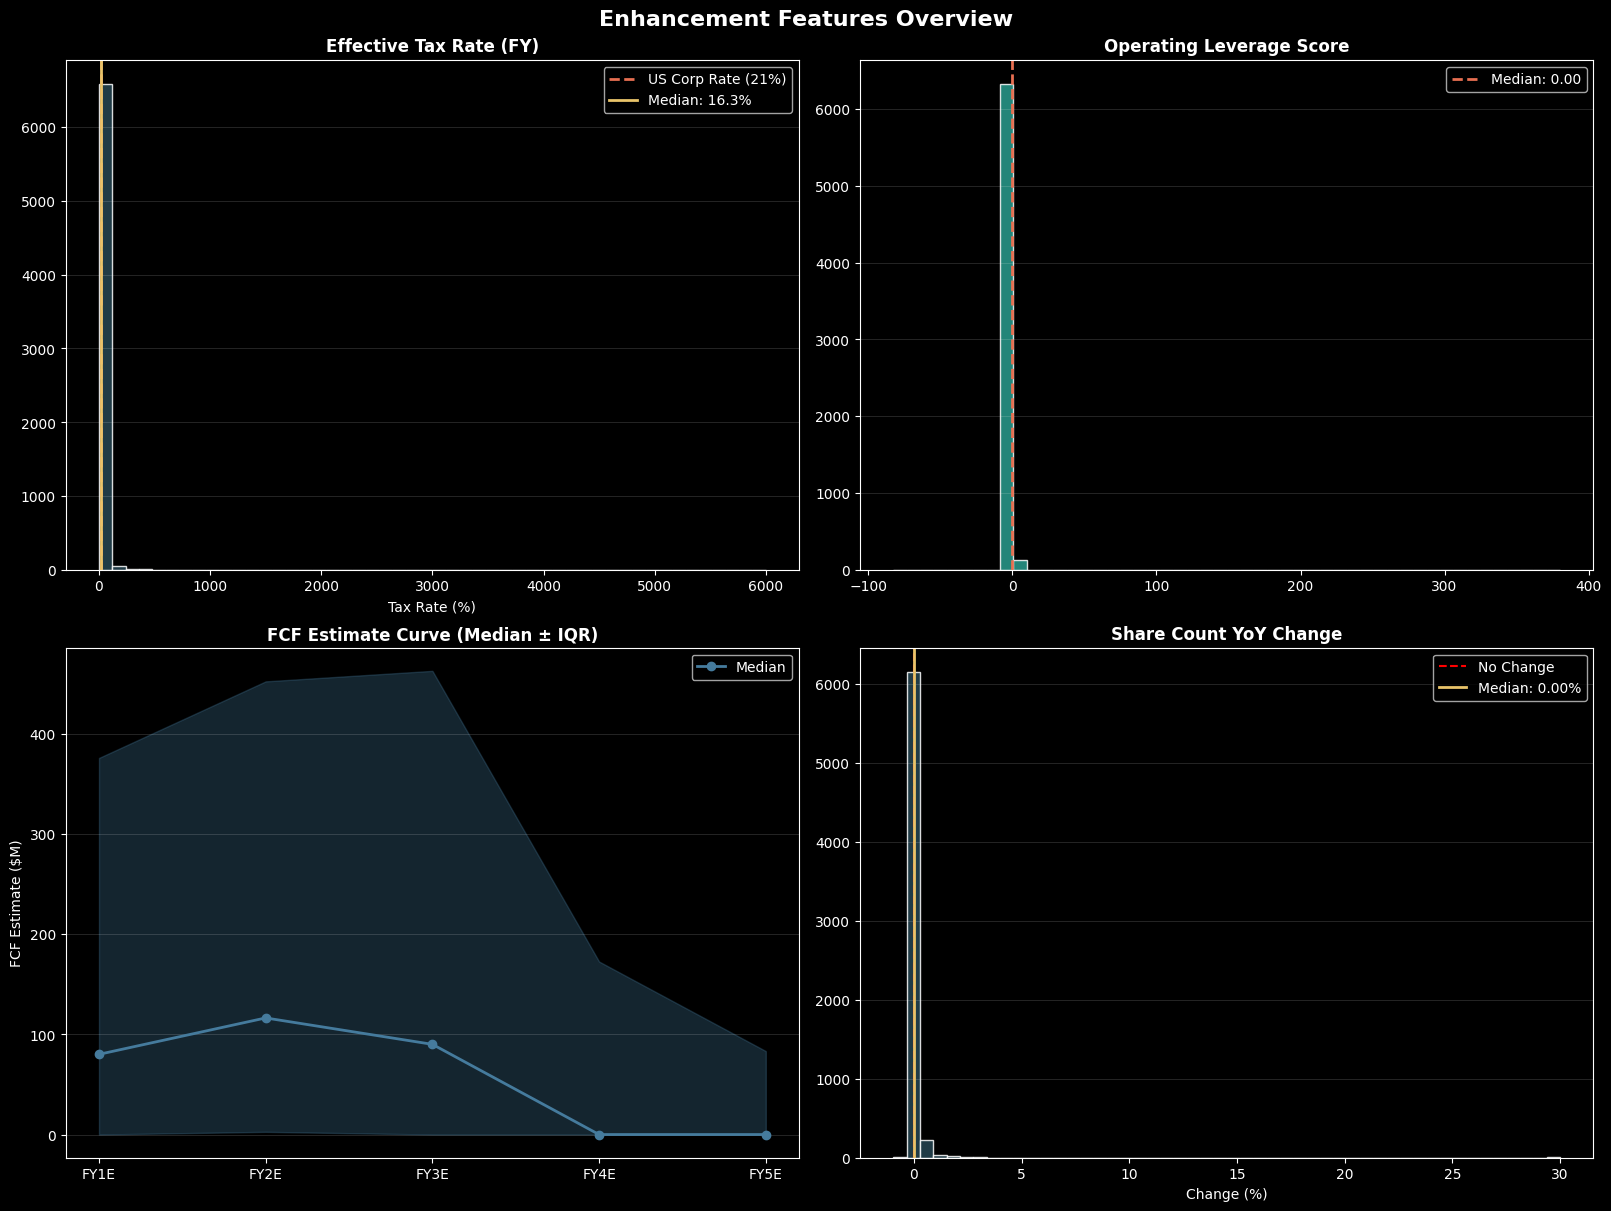

In [22]:
# Tax Rate Features (Enhancement 4)
tax_cols = [c for c in FEATURE_CATEGORIES.get("Tax Rate", []) if c in df.columns]
# OpEx Temporal (Enhancement 5)
opex_cols = [c for c in FEATURE_CATEGORIES.get("OpEx Temporal", []) if c in df.columns]
# FCF Estimates (Enhancement 9)
fcf_est_cols = [c for c in FEATURE_CATEGORIES.get("FCF Estimates", []) if c in df.columns]
# Share Dilution (Enhancement 12)
dilution_cols = [c for c in FEATURE_CATEGORIES.get("Share Dilution", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Enhancement Features Overview", fontsize=16, fontweight="bold")

# Tax rate distribution
ax = axes[0, 0]
tax_col = next((c for c in ["effective_tax_rate_fy"] if c in df.columns), None)
if tax_col:
    tax_data = df[tax_col].dropna().clip(-20, 60) * 100
    ax.hist(tax_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(21, color=COLORS["danger"], linestyle="--", lw=2, label="US Corp Rate (21%)")
    ax.axvline(tax_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {tax_data.median():.1f}%")
    ax.set_title("Effective Tax Rate (FY)", fontweight="bold")
    ax.set_xlabel("Tax Rate (%)")
    ax.legend()

# OpEx operating leverage
ax = axes[0, 1]
olev_col = next((c for c in ["operating_leverage_score"] if c in df.columns), None)
if olev_col:
    olev_data = df[olev_col].dropna()
    ax.hist(olev_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(olev_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {olev_data.median():.2f}")
    ax.set_title("Operating Leverage Score", fontweight="bold")
    ax.legend()

# FCF estimate curve
ax = axes[1, 0]
fcf_fy_cols = [c for c in ["fcf_est_avg_fy1e", "fcf_est_avg_fy2e", "fcf_est_avg_fy3e",
                           "fcf_est_avg_fy4e", "fcf_est_avg_fy5e"] if c in df.columns]
if fcf_fy_cols:
    medians = [df[c].dropna().median() for c in fcf_fy_cols]
    q25 = [df[c].dropna().quantile(0.25) for c in fcf_fy_cols]
    q75 = [df[c].dropna().quantile(0.75) for c in fcf_fy_cols]
    x = range(len(fcf_fy_cols))
    ax.fill_between(x, q25, q75, alpha=0.3, color=COLORS["info"])
    ax.plot(x, medians, "o-", color=COLORS["info"], lw=2, label="Median")
    ax.set_xticks(list(x))
    ax.set_xticklabels(["FY1E", "FY2E", "FY3E", "FY4E", "FY5E"])
    ax.set_title("FCF Estimate Curve (Median ± IQR)", fontweight="bold")
    ax.set_ylabel("FCF Estimate ($M)")
    ax.legend()

# Share dilution tracking
ax = axes[1, 1]
shares_chg = next((c for c in ["shares_yoy_change_pct"] if c in df.columns), None)
if shares_chg:
    chg_data = df[shares_chg].dropna().clip(-30, 30)
    colors_hist = [COLORS["secondary"] if v < 0 else COLORS["danger"] for v in
                   np.histogram_bin_edges(chg_data, bins=50)[:-1]]
    ax.hist(chg_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="No Change")
    ax.axvline(chg_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {chg_data.median():.2f}%")
    ax.set_title("Share Count YoY Change", fontweight="bold")
    ax.set_xlabel("Change (%)")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(True)
    a.spines["right"].set_visible(True)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 17. Dividend History & Asset Sales (Enhancements 8, 10)

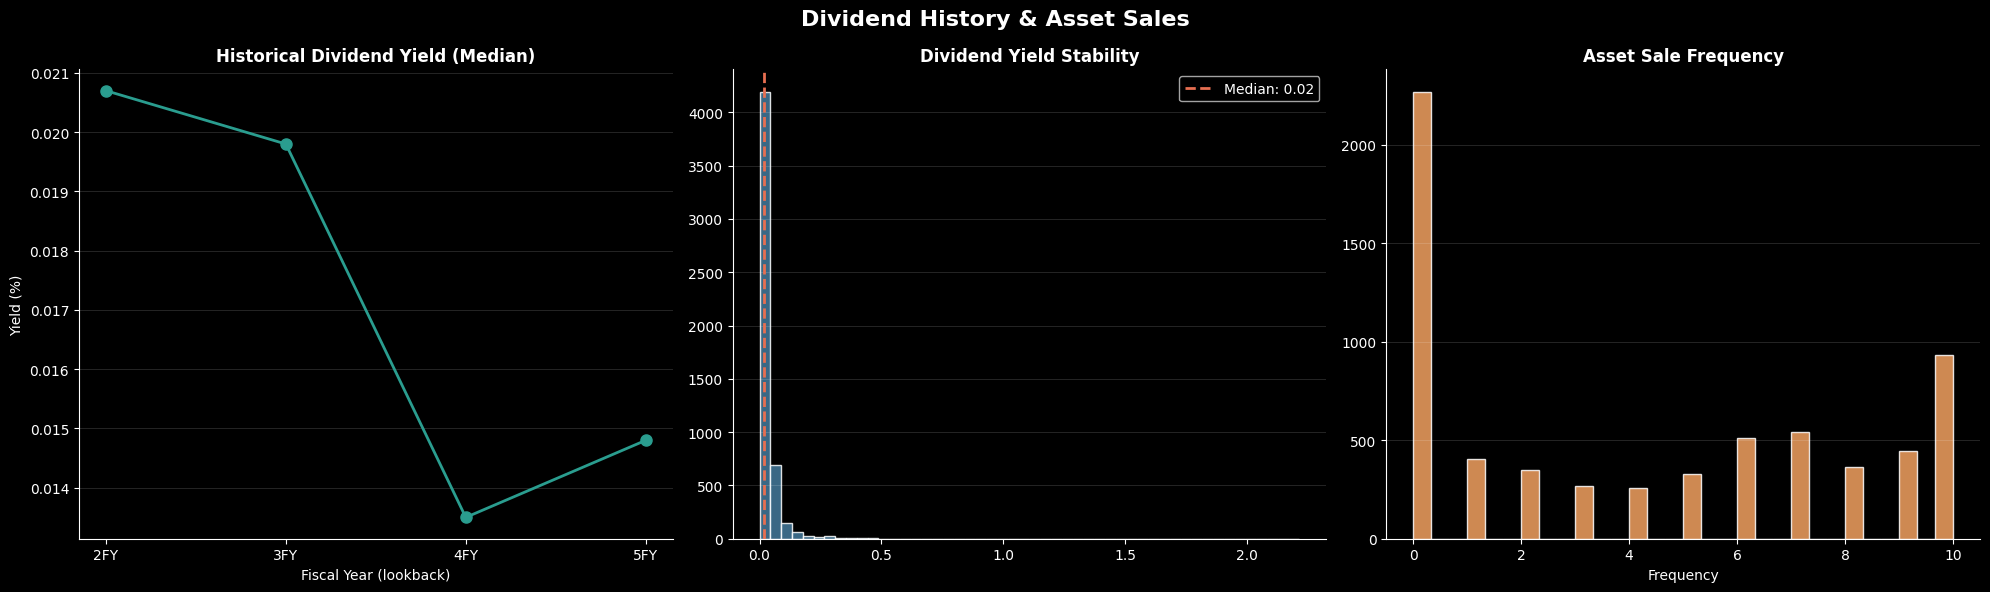

In [23]:
div_hist_cols = [c for c in FEATURE_CATEGORIES.get("Dividend History", []) if c in df.columns]
asset_cols = [c for c in FEATURE_CATEGORIES.get("Asset Sales", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Dividend History & Asset Sales", fontsize=16, fontweight="bold")

# Dividend yield history trend
ax = axes[0]
dy_hist_cols = [c for c in ["div_yield_2fyind", "div_yield_3fyind", "div_yield_4fyind",
                            "div_yield_5fyind"] if c in df.columns]
if dy_hist_cols:
    medians = [df[c].dropna().median() for c in dy_hist_cols]
    ax.plot(range(len(dy_hist_cols)), medians, "o-", color=COLORS["secondary"], lw=2, markersize=8)
    ax.set_xticks(range(len(dy_hist_cols)))
    ax.set_xticklabels(["2FY", "3FY", "4FY", "5FY"])
    ax.set_title("Historical Dividend Yield (Median)", fontweight="bold")
    ax.set_ylabel("Yield (%)")
    ax.set_xlabel("Fiscal Year (lookback)")

# Dividend yield stability
ax = axes[1]
stab_col = next((c for c in ["div_yield_stability"] if c in df.columns), None)
if stab_col:
    stab_data = df[stab_col].dropna()
    ax.hist(stab_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(stab_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {stab_data.median():.2f}")
    ax.set_title("Dividend Yield Stability", fontweight="bold")
    ax.legend()

# Asset sale frequency
ax = axes[2]
asf_col = next((c for c in ["asset_sale_frequency"] if c in df.columns), None)
if asf_col:
    asf_data = df[asf_col].dropna()
    ax.hist(asf_data, bins=30, color=COLORS["light"], alpha=0.85, edgecolor="white")
    ax.set_title("Asset Sale Frequency", fontweight="bold")
    ax.set_xlabel("Frequency")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 18. Interest Income & Employee Productivity (Enhancements 11)

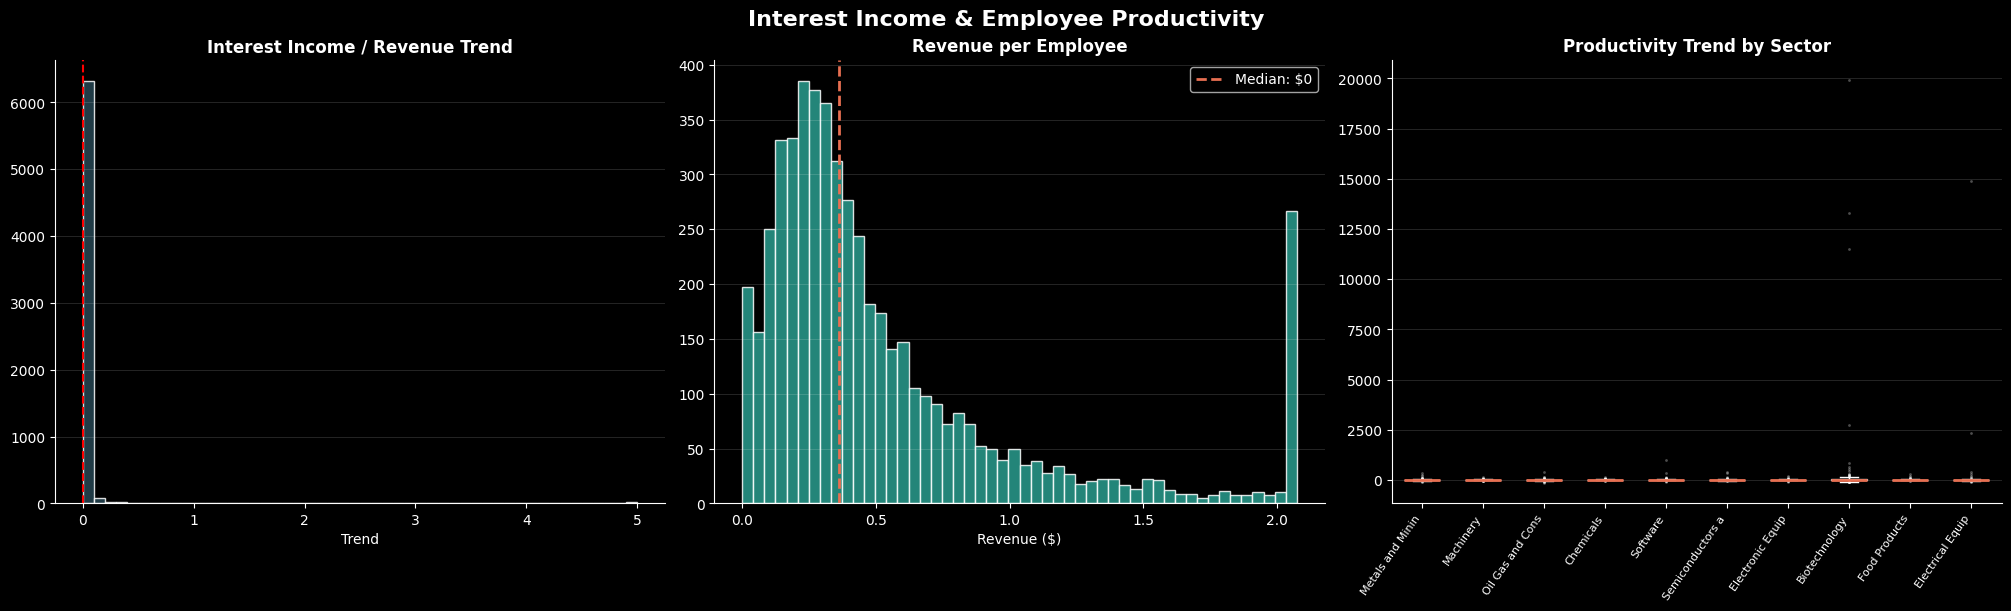

In [24]:
int_cols = [c for c in FEATURE_CATEGORIES.get("Interest Income Temporal", []) if c in df.columns]
emp_cols = [c for c in FEATURE_CATEGORIES.get("Employee Productivity", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle("Interest Income & Employee Productivity", fontsize=16, fontweight="bold")
fig.suptitle("Interest Income & Employee Productivity", fontsize=16, fontweight="bold")

# Interest income to revenue trend
ax = axes[0]
ii_col = next((c for c in ["interest_income_to_revenue_trend"] if c in df.columns), None)
if ii_col:
    ii_data = df[ii_col].dropna().clip(-5, 5)
    ax.hist(ii_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.set_title("Interest Income / Revenue Trend", fontweight="bold")
    ax.set_xlabel("Trend")

# Revenue per employee
ax = axes[1]
rpe_col = next((c for c in ["revenue_per_employee"] if c in df.columns), None)
if rpe_col:
    rpe_data = df[rpe_col].dropna().clip(0, df[rpe_col].dropna().quantile(0.95))
    ax.hist(rpe_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(rpe_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: ${rpe_data.median():,.0f}")
    ax.set_title("Revenue per Employee", fontweight="bold")
    ax.set_xlabel("Revenue ($)")
    ax.legend()

# Productivity trend by sector
ax = axes[2]
prod_col = next((c for c in ["productivity_trend"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if prod_col and sector_col:
    sectors = df[sector_col].value_counts().head(10).index
    prod_data = [df.loc[df[sector_col] == s, prod_col].dropna().values for s in sectors]
    bp = ax.boxplot(prod_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set3(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.set_title("Productivity Trend by Sector", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 19. Cross-Category Correlation Analysis

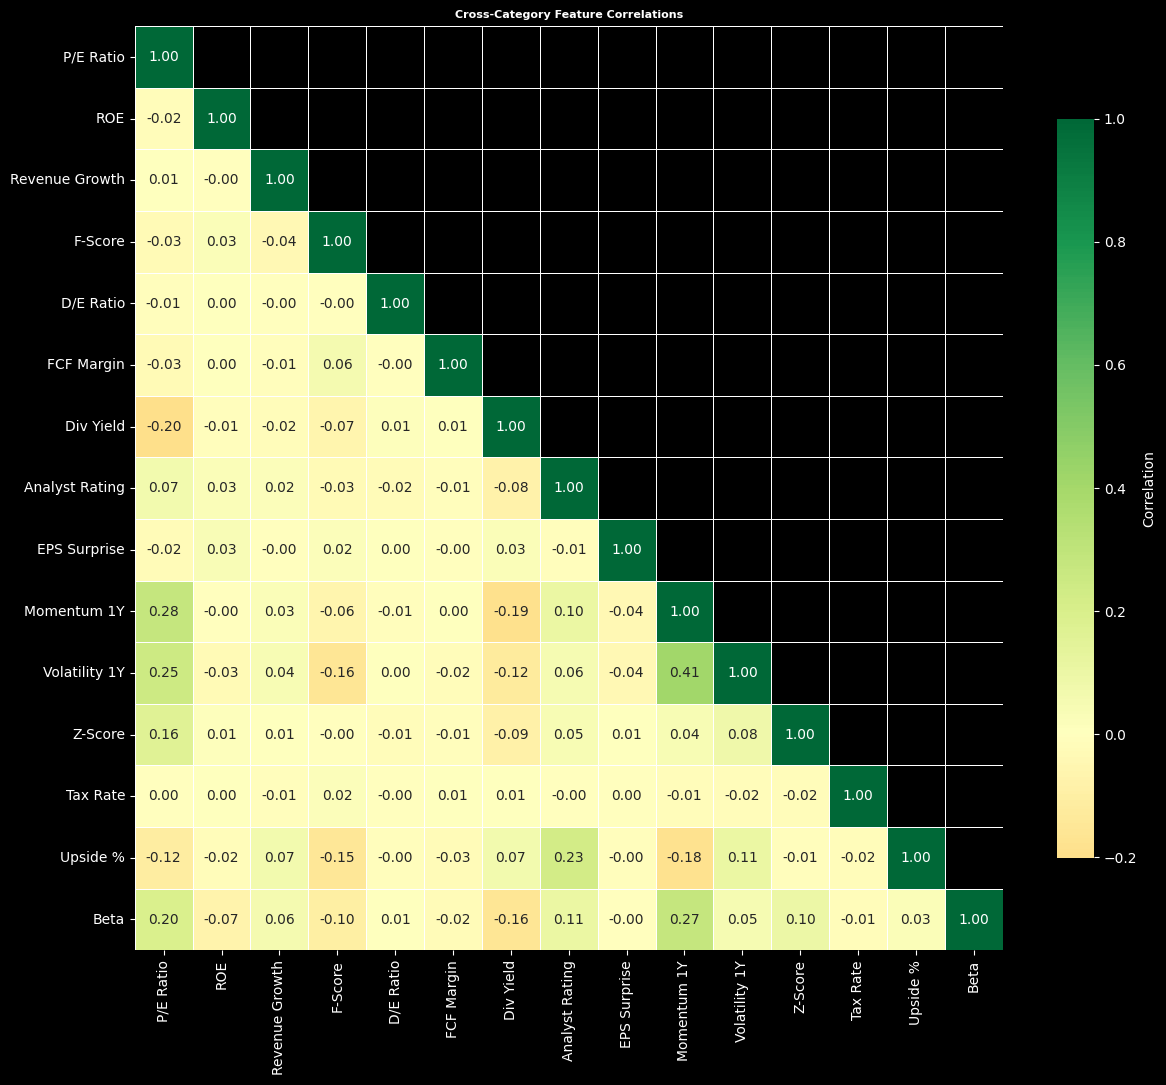

In [25]:
# Select one representative feature per category for the master correlation matrix
representative_features = {
    "P/E Ratio": "p_e_ratio",
    "ROE": "roe",
    "Revenue Growth": "revenue_growth_yoy",
    "F-Score": "piotroski_f_score",
    "D/E Ratio": "debt_to_equity",
    "FCF Margin": "fcf_margin",
    "Div Yield": "dividend_yield_ltm",
    "Analyst Rating": "analyst_rating_normalized",
    "EPS Surprise": "eps_surprise_pct",
    "Momentum 1Y": "price_momentum_1y",
    "Volatility 1Y": "volatility_1y",
    "Z-Score": "altman_z_score",
    "Tax Rate": "effective_tax_rate_fy",
    "Upside %": "upside_potential",
    "Beta": "beta_2y",
}

available_rep = {k: v for k, v in representative_features.items() if v in df.columns}
rep_df = df[list(available_rep.values())].dropna(thresh=len(available_rep) // 2)

fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=False)
corr = rep_df.corr()
corr.columns = list(available_rep.keys())
corr.index = list(available_rep.keys())
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=ax, square=False, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})
ax.set_title("Cross-Category Feature Correlations", fontsize=8, fontweight="bold")
plt.show()

## 20. Stock Screening Results

In [26]:
# Enhanced screener: high-quality stocks
quality_stocks = create_enhanced_screener(df, min_fscore=7)
print(f"Enhanced Screener (F-Score ≥ 7): {len(quality_stocks)} stocks")
if len(quality_stocks) > 0:
    display_cols = [c for c in
                    ["isin", "name", "industry", "piotroski_f_score", "last_price", "price_target", 'p_e_ratio',
                     'peg_ratio', "pe_forward_discount", "forward_pe_premium", "p_e_momentum_yoy", "altman_z_score",
                     "upside_potential", "eps_trajectory_score"] if c in quality_stocks.columns]
    display(quality_stocks[display_cols].head(50))

Enhanced Screener (F-Score ≥ 7): 36 stocks


,isin,name,industry,piotroski_f_score,last_price,price_target,p_e_ratio,peg_ratio,pe_forward_discount,forward_pe_premium,p_e_momentum_yoy,altman_z_score,upside_potential,eps_trajectory_score
33,US5128073062,Lam Research Corporation,Semiconductors and Semiconductor Equipment,9,267.7800,305.9677,64.5000,7.8453,-0.4419,-26.8217,1.6220,15.2700,17.6339,80
4463,JP3148800000,Ibiden Co.Ltd.,Electronic Equipment Instruments and Components,9,12540.0000,9523.5294,104.3000,-8.0958,-0.4506,-19.9425,2.7117,2.4100,-23.4450,80
5330,JP3110650003,Asahi Intecc Co. Ltd.,Health Care Equipment and Supplies,9,3355.0000,3829.3333,64.6000,14.6780,-0.5526,-53.2508,0.4260,13.2200,19.2250,60
643,US7512121010,Ralph Lauren Corporation,Textiles Apparel and Luxury Goods,9,371.2400,411.2625,32.0000,2.4559,-0.3406,-28.7500,0.3389,5.4000,14.4812,60
4071,JP3122400009,Advantest Corporation,Semiconductors and Semiconductor Equipment,9,29440.0000,29210.0000,127.0000,7.6313,-0.6630,-49.6063,0.7185,18.7200,1.9022,80
5350,CNE100001K48,Jiangsu Nata Opto-electronic Material Co. Ltd.,Chemicals,8,53.5700,60.0000,119.1000,5.8077,-0.3182,-31.8220,0.1485,9.4200,12.0030,100
11,US5951121038,Micron Technology Inc.,Semiconductors and Semiconductor Equipment,8,496.7200,533.7250,65.4000,-95.1131,-0.9174,-86.8502,1.6478,6.9400,10.0217,80
5465,CNE100001JP2,Loncin Motor Co. Ltd.,Automobiles,8,15.7800,19.4800,20.2000,0.5037,-0.3069,-30.6931,-0.1140,5.1200,28.6439,60
1173,US1727551004,Cirrus Logic Inc.,Semiconductors and Semiconductor Equipment,8,174.1700,160.0000,29.0000,9.4675,-0.3483,-33.7931,0.7470,11.7200,-3.8296,80
869,US6304021057,Napco Security Technologies Inc.,Electronic Equipment Instruments and Components,8,45.9100,49.6667,38.6000,1.2328,-0.2176,-19.1710,0.3640,29.2600,7.8196,80


In [27]:
# Value opportunities
value_stocks = screen_value_opportunities(df)
print(f"\nValue Opportunities: {len(value_stocks)} stocks")
if len(value_stocks) > 0:
    display_cols = [c for c in
                    ["isin", "name", "p_e_ratio", "pe_forward_discount", "forward_pe_premium", "p_e_momentum_yoy",
                     "upside_potential",
                     "price_to_tangible_book"] if c in value_stocks.columns]
    display(value_stocks[display_cols].head(50))


Value Opportunities: 1431 stocks


,isin,name,p_e_ratio,pe_forward_discount,forward_pe_premium,p_e_momentum_yoy,upside_potential,price_to_tangible_book
23,US1667641005,Chevron Corporation,27.9000,-0.4516,-45.1613,-0.0036,16.6244,2.0000
37,GB0006963689,Porvair plc,18.9000,-0.1164,-11.6402,-0.0207,36.3636,4.3000
41,US01609W1027,Alibaba Group Holding Limited,18.4000,0.1304,48.9130,0.2517,37.1333,2.8000
60,PLPLAYW00015,PlayWay S.A.,11.0000,NaN,NaN,-0.0435,10.0806,4.9000
70,IL0010958762,M.T.I Wireless Edge Ltd.,14.5000,0.0069,0.6897,0.0985,55.2556,2.6000
71,AT0000785407,Fabasoft AG,15.6000,-0.0192,-1.9231,-0.2607,115.5172,3.6000
86,US30231G1022,Exxon Mobil Corporation,22.2000,-0.3333,-33.3333,-0.0133,10.8052,2.4000
91,BMG359472021,FLEX LNG Ltd.,22.4000,-0.1830,-18.3036,0.1313,-19.3028,2.3000
109,US20825C1045,ConocoPhillips,19.2000,-0.2135,-21.3542,0.1228,14.9803,2.3000
118,US7223041028,PDD Holdings Inc.,10.2000,-0.1961,-19.6078,0.0303,48.4812,2.3000


In [28]:
# Growth momentum stocks
growth_stocks = screen_growth_momentum(df)
print(f"\nGrowth Momentum: {len(growth_stocks)} stocks")
if len(growth_stocks) > 5:
    display_cols = [c for c in ["isin", "name", "revenue_growth_yoy",
                                "eps_yoy_growth", "price_momentum_1y", "eps_momentum_yoy"] if
                    c in growth_stocks.columns]
    display(growth_stocks[display_cols].head(50))


Growth Momentum: 2830 stocks


,isin,name,revenue_growth_yoy,eps_yoy_growth,price_momentum_1y
6477,ARTRAN010011,Compañía de Transporte de Energía Eléctrica en...,19.6933,100.0000,71.4607
938,US03823U1025,Applied Optoelectronics Inc.,82.7445,85.7778,1167.9437
4138,JP3811000003,Fujikura Ltd.,23.5968,85.0000,647.4618
4446,KR7298040007,Hyosung Heavy Industries Corporation,24.7290,138.9129,710.0342
5441,TW0006442007,EZconn Corporation,71.8979,70.4545,457.0370
387,CA15101Q2071,Celestica Inc.,28.4564,99.4475,340.4915
4320,KR7267260008,HD Hyundai Electric Co. Ltd.,25.6073,49.3644,325.9386
4703,TW0006223001,MPI Corporation,37.5969,44.5946,646.3884
4820,INE200A01026,GE Vernova T&D India Limited,32.1497,250.0000,205.6765
4273,TW0003017000,Asia Vital Components Co. Ltd.,103.6833,141.5385,567.8005


In [29]:
# Dividend quality stocks
div_stocks = screen_dividend_quality(df)
print(f"\nDividend Quality: {len(div_stocks)} stocks")
if len(div_stocks) > 0:
    display_cols = [c for c in ["isin", "name", "dividend_yield_ltm",
                                "dividend_streak", "fcf_dividend_coverage"] if c in div_stocks.columns]
    display(div_stocks[display_cols].head(50))


Dividend Quality: 570 stocks


,isin,name,dividend_yield_ltm,dividend_streak,fcf_dividend_coverage
6633,BREVENACNOR8,Even Construtora e Incorporadora S.A.,0.1031,2,0.5924
1323,US2058871029,Conagra Brands Inc.,0.0987,1,1.2582
5737,ID1000095706,PT Unilever Indonesia Tbk,0.0881,2,0.9682
2175,VGG6564A1057,Nomad Foods Limited,0.0791,1,2.7624
3550,NO0003921009,DNO ASA,0.0764,6,0.6806
2219,US76009N1000,Upbound Group Inc.,0.0762,8,2.7169
6580,BRCSEDACNOR9,Cruzeiro do Sul Educacional S.A.,0.0762,3,4.3807
3526,NO0010716582,Aker Solutions ASA,0.0754,3,1.3709
564,US5007541064,The Kraft Heinz Company,0.0730,1,1.9289
2482,NO0013135368,Solstad Maritime ASA,0.0718,0,1.5525


In [30]:
# Financially healthy stocks
healthy_stocks = screen_financial_health(df)
print(f"\nFinancial Health: {len(healthy_stocks)} stocks")
if len(healthy_stocks) > 0:
    display_cols = [c for c in ["isin", "name", "altman_z_score", "piotroski_f_score",
                                "current_ratio", "interest_coverage"] if c in healthy_stocks.columns]
    display(healthy_stocks[display_cols].head(50))


Financial Health: 1036 stocks


,isin,name,altman_z_score,piotroski_f_score,current_ratio,interest_coverage
6649,MX01GI000030,Grupo Industrial Saltillo S.A.B. de C.V.,NaN,6,1.2000,-1.1915
2,US30054Y1073,Evommune Inc.,15.9900,0,8.6000,8107.0000
4,GB00BSLKLP68,Brave Bison Group plc,3.8800,3,1.0000,-4.3214
6647,TN0007270010,Tunisie Profilés Aluminium Société Anonyme,4.0300,6,1.8000,-5.2614
18,FR0000066722,Guillemot Corporation S.A.,NaN,4,2.1000,-2.8421
21,US6323071042,Natera Inc.,19.8300,2,3.4000,76.1450
6631,BRKEPLACNOR1,Kepler Weber S.A.,3.4000,3,2.0000,-3.5917
6550,TREMAVI00037,Mavi Giyim Sanayi ve Ticaret A.S.,4.7800,4,1.6000,-2.3813
6534,ZAE000005153,Omnia Holdings Limited,3.1900,5,1.6000,-7.8460
6526,TREDOTO00013,Dogus Otomotiv Servis ve Ticaret A.S.,3.5000,2,1.4000,-1.7104


## 21. Composite Rankings

Ranked 6668 stocks by composite score

Top 50 by Composite Score:


,isin,name,industry,composite_score
643,US7512121010,Ralph Lauren Corporation,Textiles Apparel and Luxury Goods,100.0000
1773,US5006432000,Korn Ferry,Professional Services,97.5000
33,US5128073062,Lam Research Corporation,Semiconductors and Semiconductor Equipment,97.5000
0,US0378331005,Apple Inc.,Technology Hardware Storage and Peripherals,97.5000
1393,US1096411004,Brinker International Inc.,Hotels Restaurants and Leisure,97.2222
1029,US03820C1053,Applied Industrial Technologies Inc.,Trading Companies and Distributors,97.2222
3623,SE0008014476,Plejd AB (publ),Electrical Equipment,97.2222
743,US11133T1034,Broadridge Financial Solutions Inc.,Professional Services,97.2222
319,US1999081045,Comfort Systems USA Inc.,Construction and Engineering,97.2222
523,US1475281036,Casey's General Stores Inc.,Consumer Staples Distribution and Retail,97.2222


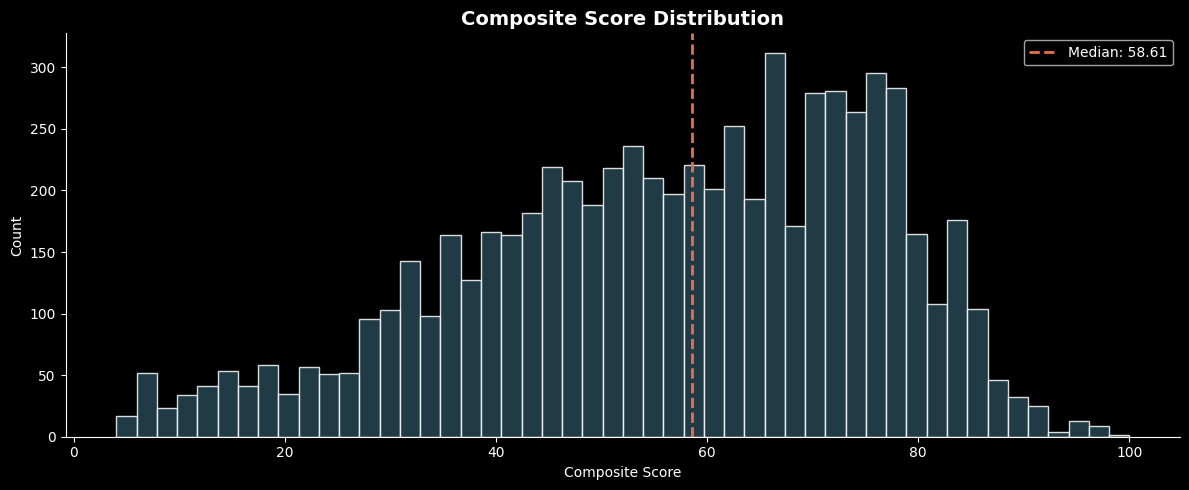

In [31]:
# Rank stocks by composite score
ranked_df = rank_stocks_by_composite_score(df)
print(f"Ranked {len(ranked_df)} stocks by composite score")
if "composite_score" in ranked_df.columns:
    display_cols = [c for c in ["isin", "name", "industry", "composite_score"]
                    if c in ranked_df.columns]
    print("\nTop 50 by Composite Score:")
    display(ranked_df[display_cols].head(50))

    # Composite score distribution
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(ranked_df["composite_score"].dropna(), bins=50, color=COLORS["primary"],
            alpha=0.85, edgecolor="white")
    ax.axvline(ranked_df["composite_score"].median(), color=COLORS["danger"],
               linestyle="--", lw=2, label=f"Median: {ranked_df['composite_score'].median():.2f}")
    ax.set_title("Composite Score Distribution", fontsize=14, fontweight="bold")
    ax.set_xlabel("Composite Score")
    ax.set_ylabel("Count")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

## 22. Statistical Analysis: Bayesian Category Analysis

In [32]:
# Bayesian analysis on ALL feature categories (excluding "direct" calculation_type features)

# Build a set of features with "direct" calculation_type to exclude
direct_features = set(
    feature_cat.loc[feature_cat["calculation_type"] == "direct", "feature_alias"].tolist()
)
print(f"Excluding {len(direct_features)} features with calculation_type='direct'")

for cat_name, features in FEATURE_CATEGORIES.items():
    # Filter out "direct" features and keep only those present in df
    available = [f for f in features if f in df.columns and f not in direct_features]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Bayesian Analysis: {cat_name} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = bayesian_category_analysis(df, cat_name, available)
        if isinstance(result, dict):
            for feat, stats in result.items():
                if isinstance(stats, dict):
                    print(f"\n  {feat}:")
                    for k, v in stats.items():
                        if isinstance(v, (int, float)):
                            print(f"    {k}: {v:.4f}")
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {cat_name}: {skipped_reason}")

Excluding 405 features with calculation_type='direct'

  Bayesian Analysis: Accounting Quality (20 features)

  asset_sale_frequency:
    n_obs: 6668.0000
    sample_mean: 4.1450
    sample_std: 3.8564
    posterior_mean: 4.1449
    posterior_std: 0.0472
    ci_95_low: 4.0524
    ci_95_high: 4.2375
    prob_positive: 1.0000

  asset_sale_trend:
    n_obs: 6668.0000
    sample_mean: -3.5647
    sample_std: 188.4355
    posterior_mean: -3.3844
    posterior_std: 2.2485
    ci_95_low: -7.7916
    ci_95_high: 1.0227
    prob_positive: 0.0661

  tax_rate_yoy_change:
    n_obs: 6668.0000
    sample_mean: -0.0795
    sample_std: 4.7594
    posterior_mean: -0.0795
    posterior_std: 0.0583
    ci_95_low: -0.1937
    ci_95_high: 0.0347
    prob_positive: 0.0863

  tax_rate_qoq_change:
    n_obs: 6668.0000
    sample_mean: -0.0309
    sample_std: 2.3760
    posterior_mean: -0.0309
    posterior_std: 0.0291
    ci_95_low: -0.0879
    ci_95_high: 0.0262
    prob_positive: 0.1445

  tax_rate_stabil

## 23. Distribution Fitting by Category

In [33]:
# Fit statistical distributions to ALL feature categories
# (reuses the same direct_features exclusion set built in cell 22)

for cat_name, features in FEATURE_CATEGORIES.items():
    available = [f for f in features if f in df.columns and f not in direct_features]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Distribution Fitting: {cat_name} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = fit_distributions_by_category(df, cat_name, available, n_simulations=500)
        if isinstance(result, dict):
            for feat, info in result.items():
                if isinstance(info, dict) and "best_distribution" in info:
                    print(
                        f"  {feat}: best_distribution={info['best_distribution']}, "
                        f"aic={info.get('aic', 'N/A'):.4f}, "
                        f"params={info.get('params', 'N/A')}, "
                        f"simulated_mean={info.get('simulated_mean', 'N/A'):.4f}, "
                        f"simulated_std={info.get('simulated_std', 'N/A'):.4f}, "
                        f"cvar_5_pct={info.get('cvar_5_pct', 'N/A'):.4f}"
                    )
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {cat_name}: {skipped_reason}")


  Distribution Fitting: Accounting Quality (20 features)
  asset_sale_frequency: best_distribution=skew_normal, aic=32805.2290, params=(np.float64(2021588.328886916), np.float64(-1.390869483993008e-05), np.float64(5.661012041358012)), simulated_mean=4.3151, simulated_std=3.4205, cvar_5_pct=0.1270
  asset_sale_trend: best_distribution=skew_normal, aic=47088.3818, params=(np.float64(-1.031411028312103), np.float64(5.753636784104087), np.float64(10.8742169167971)), simulated_mean=-0.7111, simulated_std=8.6279, cvar_5_pct=-19.1480
  tax_rate_yoy_change: best_distribution=skew_normal, aic=-4672.0291, params=(np.float64(0.9593115602509934), np.float64(-0.11962088931302424), np.float64(0.2033435616870175)), simulated_mean=-0.0203, simulated_std=0.1750, cvar_5_pct=-0.3615
  tax_rate_qoq_change: best_distribution=student_t, aic=-14650.9107, params=(np.float64(0.45323411603621555), np.float64(-0.0001282551042587927), np.float64(0.006607084283152362)), simulated_mean=-3.3373, simulated_std=53.62

## 24. Sector-Level Summary Dashboard

Sector-Level Summary:


,count,median_pe,median_roe,median_momentum,median_upside
industry,,,,,
Metals and Mining,354,24.3000,0.0747,85.0667,19.0694
Machinery,324,28.7000,0.1121,30.3656,14.7199
Oil Gas and Consumable Fuels,294,16.1000,0.0956,42.3336,12.3003
Chemicals,284,28.0500,0.0628,34.5035,11.0961
Software,257,31.2000,0.0823,-8.9243,40.0000
Semiconductors and Semiconductor Equipment,256,62.6000,0.0802,112.9482,-1.7637
Electronic Equipment Instruments and Components,254,42.7500,0.1007,64.1012,8.7855
Biotechnology,242,27.6000,-0.2906,43.6939,46.7908
Food Products,239,17.7000,0.1158,6.2065,16.9331


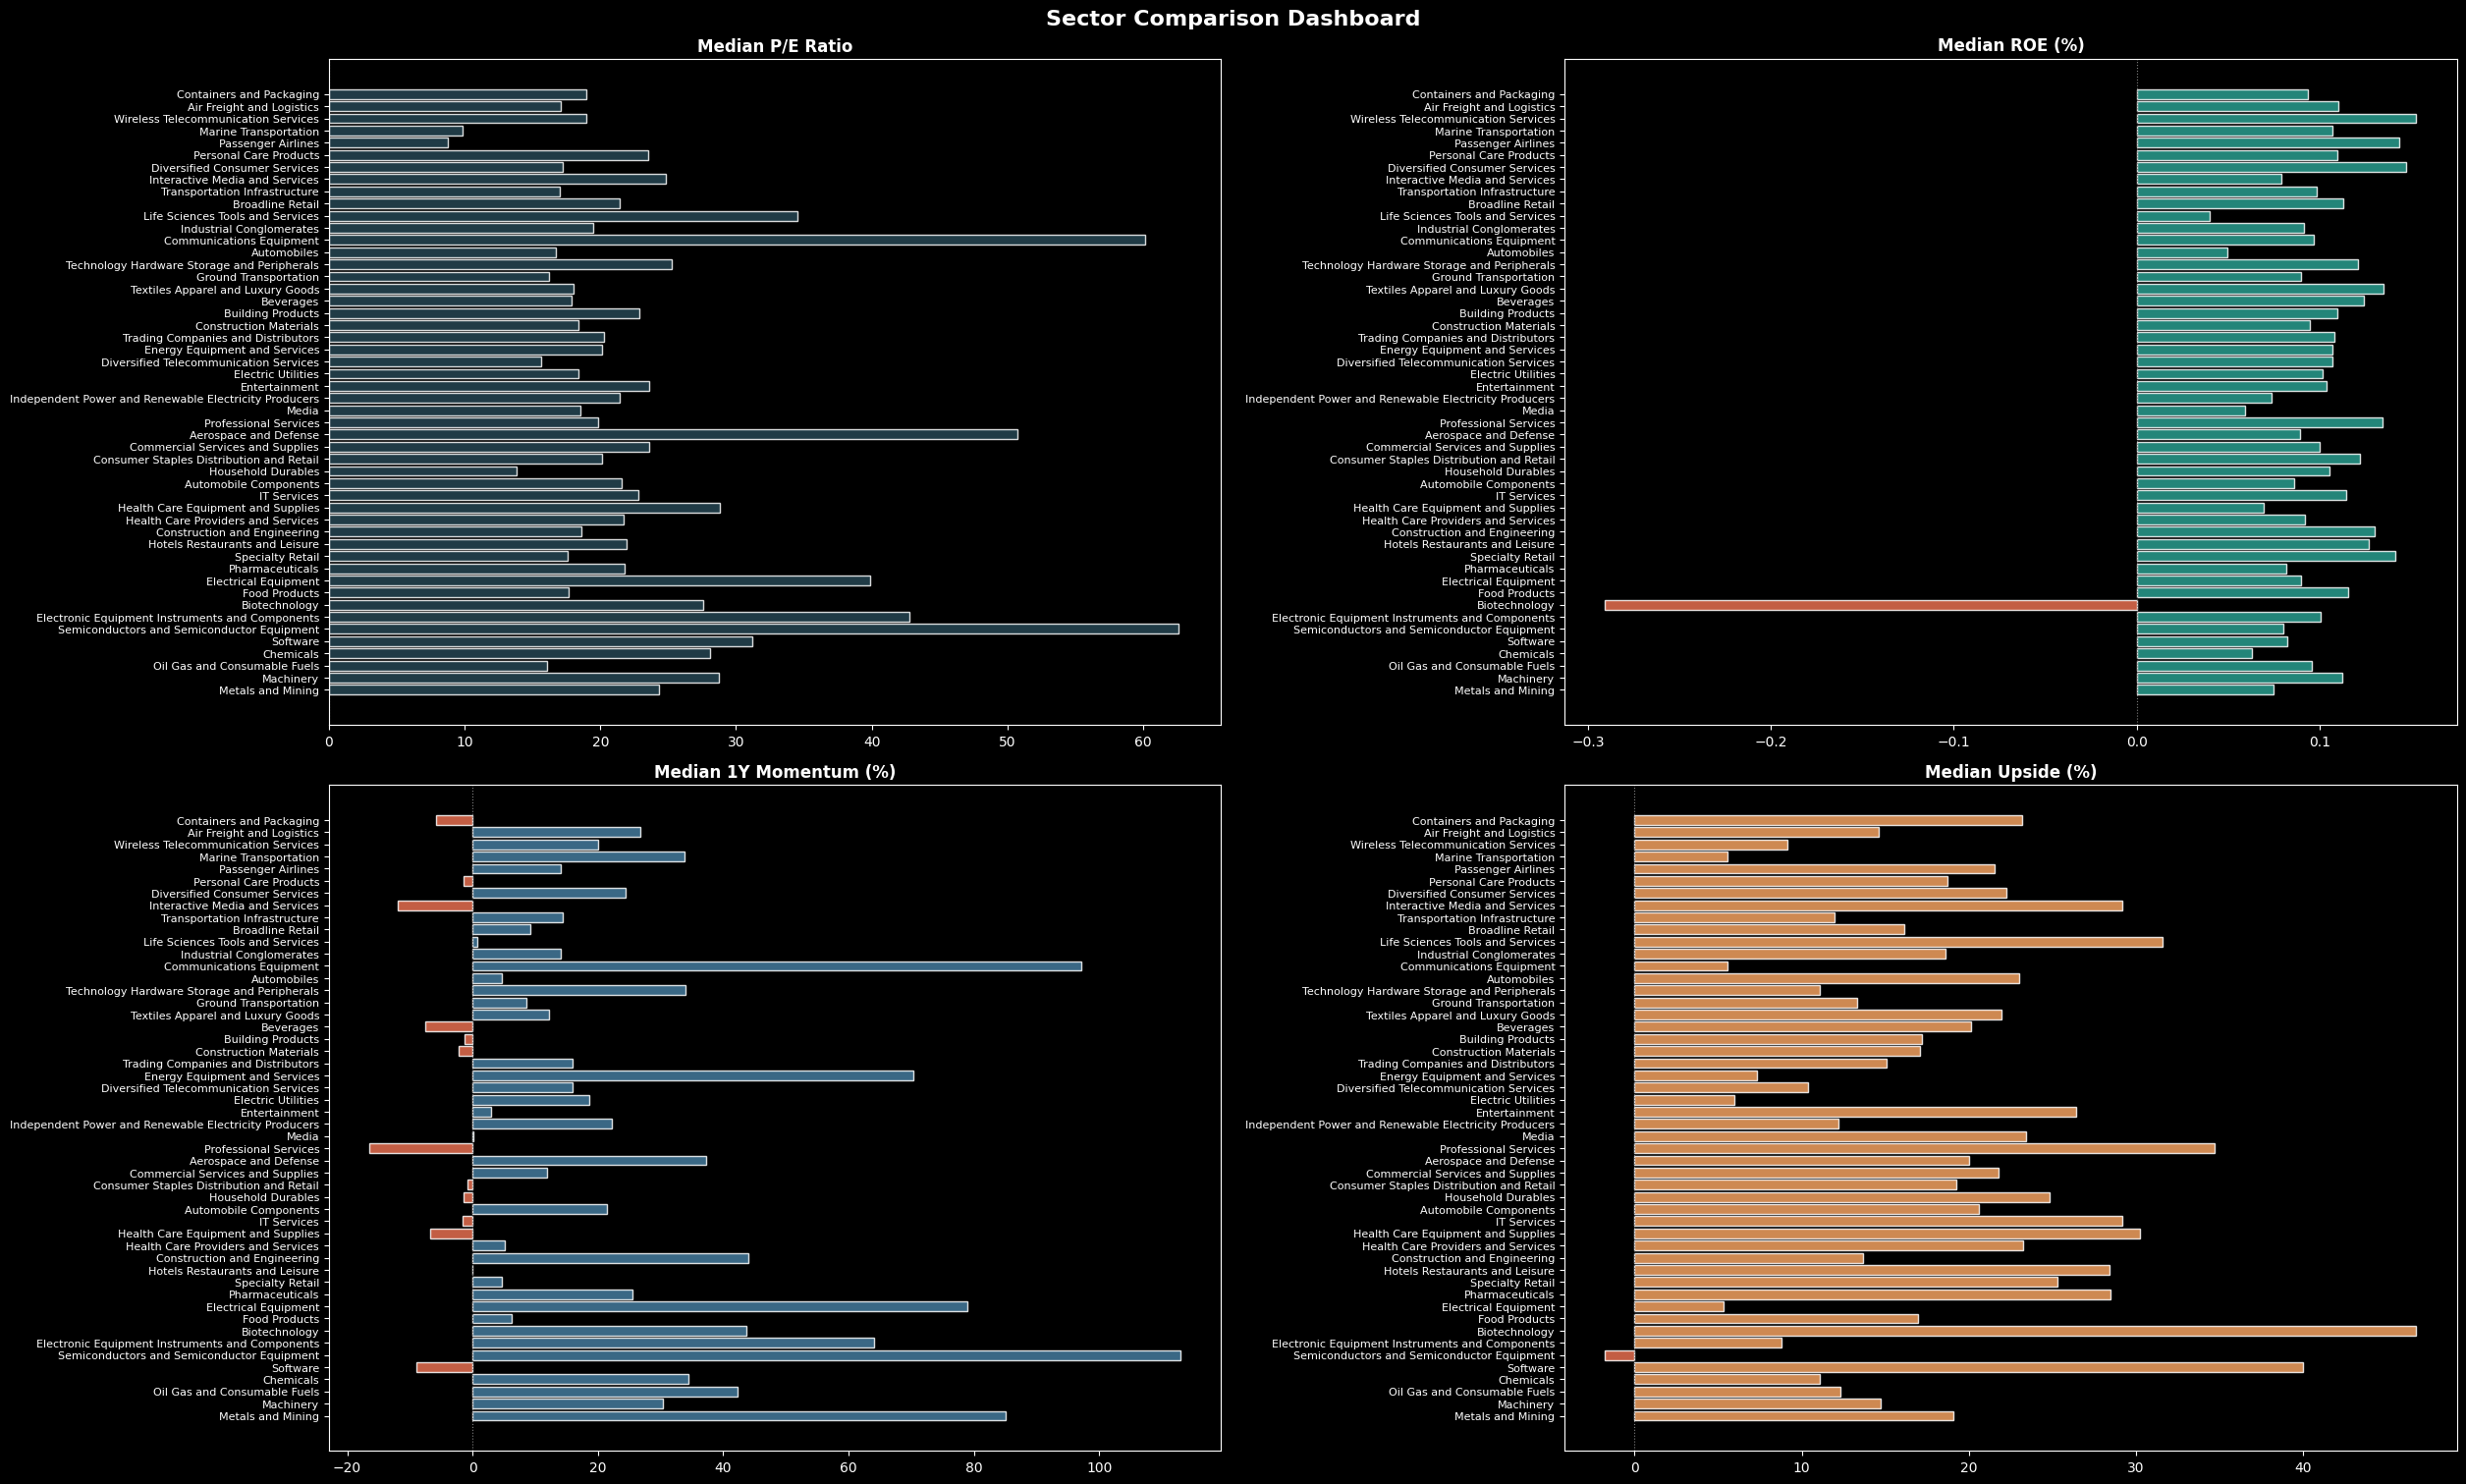

In [34]:
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if sector_col:
    sector_metrics = df.groupby(sector_col).agg(
        count=("isin", "count"),
        median_pe=("p_e_ratio", "median") if "p_e_ratio" in df.columns else ("isin", "count"),
        median_roe=("roe", "median") if "roe" in df.columns else ("isin", "count"),
        median_momentum=("price_momentum_1y", "median") if "price_momentum_1y" in df.columns else ("isin", "count"),
        median_upside=("upside_potential", "median") if "upside_potential" in df.columns else ("isin", "count"),
    ).sort_values("count", ascending=False)

    print("Sector-Level Summary:")
    display(sector_metrics.head(50))

    # Sector comparison radar-style bar chart
    fig, axes = plt.subplots(2, 2, figsize=(25, 15), constrained_layout=True)
    fig.suptitle("Sector Comparison Dashboard", fontsize=16, fontweight="bold")

    metrics_to_plot = [
        ("median_pe", "Median P/E Ratio", COLORS["primary"]),
        ("median_roe", "Median ROE (%)", COLORS["secondary"]),
        ("median_momentum", "Median 1Y Momentum (%)", COLORS["info"]),
        ("median_upside", "Median Upside (%)", COLORS["light"]),
    ]

    top_sectors = sector_metrics.head(50)
    for idx, (col, title, color) in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        if col in top_sectors.columns:
            vals = top_sectors[col].fillna(0)
            bar_colors = [COLORS["danger"] if v < 0 else color for v in vals]
            ax.barh(top_sectors.index, vals, color=bar_colors, edgecolor="white", alpha=0.85)
            ax.set_title(title, fontweight="bold")
            ax.axvline(0, color="grey", linestyle=":", lw=0.8)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.tick_params(axis="y", labelsize=8)

    plt.show()

## 25. Core PML Bayesian Modeling (PyMC & ArviZ)

This section implements the next-generation probabilistic models using PyMC for full Bayesian inference. Unlike the baseline models above, these models produce full posterior distributions, allowing for advanced risk analysis and uncertainty quantification.

### 25.1 Kalman Filter Price Targets
Noise-reduced price target signals using state-space modeling.


Capping Kalman observations from 6668 to 1000 for tractability.
Prepared Kalman inputs: 1000 rows, dtype=float64
Running Kalman Filter for AEA001901015 (1000 observations)...


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_subtensor_merge
ERROR (pytensor.graph.rewriting.basic): node: Subtensor{i}(Subtensor{start:}.0, 0)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
        fgraph, node, enforce_tracks=enforce_tracks
    )
  File "C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytensor\graph\rewriting\basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ~~~~~~~^^^^^^^^^^^^^^
  File "C:\Users\markm\AppData\Local\Programs\Python\Python314\L

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.04,1023
,1000,0,0.05,1023


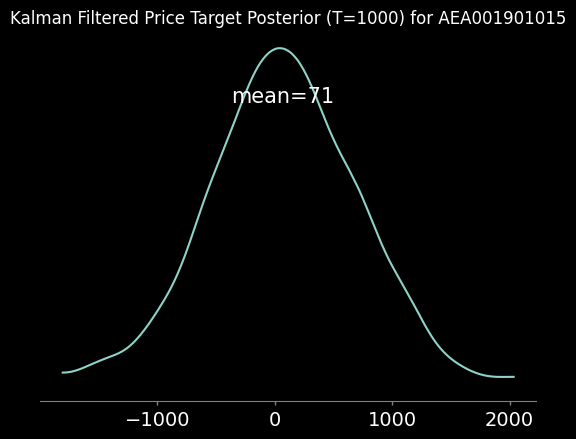

In [35]:
# ── Prepare Kalman Filter inputs (template: EarningsBeatBayesian) ──
# Mirror the dataframe handling used for EarningsBeatBayesian:
#   1. Detect canonical id column (`isin` preferred, fallback to `isin`).
#   2. Drop NaNs and de-duplicate by id so each entity contributes once.
#   3. Cast to explicit dtypes (float64) so PyTensor does NOT infer an
#      int8 default that overflows the `local_subtensor_merge` rewrite
#      (the source of the 6674-out-of-bounds warnings).
#   4. Cap the cross-sectional series length to keep the GaussianRandomWalk
#      tractable.
pt_col = "price_target"
# Fall back to ticker if isin is missing (fix the tautology)
id_col = "isin" if "isin" in df.columns else "ticker"

# Construct the validity mask that was missing
valid_mask = (
        df[id_col].notna()
        & df[pt_col].notna()
        & np.isfinite(pd.to_numeric(df[pt_col], errors="coerce"))
)

cols = list(dict.fromkeys([id_col, "isin", pt_col]))  # preserves order, removes dupes
kf_df = (
    df.loc[valid_mask, cols]
    .drop_duplicates(subset=id_col)
    .sort_values(id_col)
    .reset_index(drop=True)
)

# Bound the observation length — the original 6673 obs triggered an
# int8 overflow inside pytensor.tensor.rewriting.subtensor.merge_two_slices.
MAX_KF_OBS = 1000
if len(kf_df) > MAX_KF_OBS:
    print(f"Capping Kalman observations from {len(kf_df)} to {MAX_KF_OBS} for tractability.")
    kf_df = kf_df.head(MAX_KF_OBS).reset_index(drop=True)

pt_values = np.asarray(kf_df[pt_col].to_numpy(), dtype="float64")
kf_ids = kf_df[id_col].astype(str).to_numpy()

print(f"Prepared Kalman inputs: {len(kf_df)} rows, dtype={pt_values.dtype}")

if len(pt_values) >= 5:
    kf_model = KalmanFilterPriceTarget()
    example_isin = str(kf_df["isin"].iloc[0])
    print(f"Running Kalman Filter for {example_isin} ({len(pt_values)} observations)...")
    kf_idata, kf_modelobj = kf_model.fit(
        price_targets=pt_values,
        isin=example_isin,
        samples=500,
        tune=500,
        chains=2,
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    # Plotting filtered state at the final time index
    # NOTE: arviz>=0.22 delegates HDI computation to arviz_stats, whose `hdi`
    # function no longer accepts the legacy `hdi_prob`/`multimodal` kwargs that
    # `plot_posterior` still forwards. Until that upstream bug is fixed, we
    # disable the HDI overlay (`hdi_prob="hide"`) to avoid the TypeError.
    az.plot_posterior(
        kf_idata,
        var_names=["state"],
        coords={"time": [len(pt_values) - 1]},
        hdi_prob="hide",
    )
    plt.title(f"Kalman Filtered Price Target Posterior (T={len(pt_values)}) for {example_isin}")
    plt.show()
else:
    print(f"Insufficient price target data ({len(pt_values)} obs) — skipping Kalman Filter.")


### 25.5 Accounting Anomaly Detection (Bayesian)
Multi-layered statistical anomaly detection via Mahalanobis distance.


In [ ]:
anomaly_bayesian = AccountingAnomalyBayesian(threshold=2.5)

# Multi-category anomaly features verified against DDL
anomaly_feature_cols = [
    "eps_surprise_pct", "eps_adjustment_ratio", "gaap_adj_eps_gap_pct",
    "ebitda_adjustment_ratio", "earnings_quality_score",
    "ni_adjustment_ratio", "cfo_to_net_income", "accounting_quality_score",
    "debt_to_equity", "current_ratio",
]
anomaly_features = [f for f in anomaly_feature_cols if f in df.columns][:10]

if len(anomaly_features) >= 3:
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    feat_vals = scaler.fit_transform(df[anomaly_features].fillna(0).values)

    print(f"Running Bayesian Anomaly Detection using: {anomaly_features}")
    anomaly_idata, anomaly_model = anomaly_bayesian.fit(
        feature_values=feat_vals,
        isins=df["isin"].values,
        feature_names=anomaly_features,
        samples=1000,
        tune=500,
        chains=2,
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    # Visualization
    az.plot_forest(anomaly_idata, var_names=["anomaly_prob"], combined=True)
    plt.title("Bayesian Anomaly Probability Posterior")
    plt.show()


Running Bayesian Anomaly Detection using: ['eps_surprise_pct', 'eps_adjustment_ratio', 'gaap_adj_eps_gap_pct', 'ebitda_adjustment_ratio', 'earnings_quality_score', 'ni_adjustment_ratio', 'cfo_to_net_income', 'accounting_quality_score', 'debt_to_equity', 'current_ratio']


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.05,63
,1500,0,0.06,63


### 25.6 Credit Risk / Distress Estimation
Bayesian distress estimation with Altman Z-score and Debt-to-Equity signals.


In [ ]:
credit_bayesian = CreditRiskBayesian()
z_col = "altman_z_score"  # DDL: numeric, Quality & Risk category
de_col = "debt_to_equity"  # DDL: numeric, Leverage & Liquidity category

valid_mask = df[z_col].notna() & df[de_col].notna()
cr_df = df[valid_mask]

if len(cr_df) > 0:
    print(f"Running Bayesian Credit Risk Model for {len(cr_df)} stocks...")
    # Pass combined_distress_score as observed distress signal when available
    distress_obs = (cr_df["combined_distress_score"].values / 100
                    if "combined_distress_score" in cr_df.columns else None)

    credit_idata, credit_model = credit_bayesian.fit(
        z_scores=cr_df[z_col].values,
        debt_to_equity=cr_df[de_col].values,
        isin=cr_df["isin"].values,
        sectors=cr_df["sector"].values if "sector" in cr_df.columns else None,
        distress_observed=distress_obs,
        samples=1000,
        tune=500,
        chains=2,
        parameterization="non_centered",
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    az.plot_forest(credit_idata, var_names=["distress_prob"], combined=True)
    plt.title("Credit Distress Probability Posterior")
    plt.show()


### 25.7 Dividend Safety Analysis
Dividend cut probability with FCF coverage and payout ratios.


In [ ]:
div_bayesian = DividendSafetyBayesian()
payout_col = "dividend_payout_ratio"  # DDL: numeric, Dividends category
fcf_cov_col = "fcf_dividend_coverage"  # DDL: numeric, Dividends category

# Filter to dividend-paying stocks only
div_mask = (df[payout_col].notna() & (df[payout_col] > 0) &
            df[fcf_cov_col].notna())
div_df = df[div_mask]

if len(div_df) > 0:
    print(f"Running Bayesian Dividend Safety Model for {len(div_df)} dividend-paying stocks...")
    div_idata, div_model = div_bayesian.fit(
        payout_ratios=div_df[payout_col].values,
        fcf_coverage=div_df[fcf_cov_col].clip(lower=0.01).values,
        isin=div_df["isin"].values,
        samples=1000,
        tune=500,
        chains=2,
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    az.plot_forest(div_idata, var_names=["cut_prob"], combined=True)
    plt.title("Dividend Cut Probability Posterior")
    plt.show()


### 25.8 Earnings Beat Probability
Hierarchical Beta-Binomial model for earnings beat prediction.


In [ ]:
earnings_bayesian = EarningsBeatBayesian()
beats_col = "eps_positive_years"  # DDL: integer — years with positive EPS (proxy for beats)
total_periods = 10  # assume 10-year lookback window for eps_positive_years

if beats_col in df.columns:
    valid_mask = df[beats_col].notna()
    eb_df = df[valid_mask]

    if len(eb_df) > 0:
        print(f"Running Bayesian Earnings Beat Model for {len(eb_df)} stocks...")
        n_total = np.full(len(eb_df), total_periods, dtype="int32")
        n_beats = np.clip(eb_df[beats_col].astype(int).values, 0, total_periods)

        earnings_idata, earnings_model = earnings_bayesian.fit(
            n_beats=n_beats, n_total=n_total, isin=eb_df["isin"].values,
            sectors=eb_df["sector"].values if "sector" in eb_df.columns else None,
            samples=500, tune=500, chains=2, target_accept=0.9,
            parameterization="marginalized",
            nuts_sampler="nutpie",
            idata_kwargs={"log_likelihood": False},
        )

        fig = create_beat_probability_posterior(earnings_idata, title="Earnings Beat Probability Posterior")
        fig.show()


### 25.9 Price Target Achievement
Probability-weighted expected returns with risk adjustment.


In [ ]:
pt_bayesian = PriceTargetAchievement()
upside_col = "upside_potential"  # DDL: numeric, Analyst Sentiment category
disp_col = "price_target_spread_pct"  # DDL: numeric, Analyst Sentiment category

valid_mask = df[upside_col].notna()
pt_df = df[valid_mask]

if len(pt_df) > 0:
    print(f"Running Bayesian Price Target Achievement Model for {len(pt_df)} stocks...")
    disp_values = pt_df[disp_col].fillna(20).values / 100 if disp_col in pt_df.columns \
        else np.full(len(pt_df), 0.2)

    pt_idata, pt_model = pt_bayesian.fit(
        consensus_upside=pt_df[upside_col].values / 100,
        analyst_dispersion=np.clip(disp_values, 0.01, None),
        isin=pt_df["isin"].values,
        samples=1000,
        tune=500,
        chains=2,
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    az.plot_forest(pt_idata, var_names=["achieve_prob"], combined=True)
    plt.title("Price Target Achievement Probability Posterior")
    plt.show()


### 25.10 Out-of-sample prediction via `pm.set_data`

Each refactored `fit()` now returns `(idata, model)` and stashes them on
`self.idata_` / `self.model_`, enabling cohort swap-in for forecasting
without rebuilding the model graph.

```python
import pymc as pm

with credit_model:
    pm.set_data({
        "z_score_data": new_z,
        "de_data": new_de,
        "distress_target": np.zeros_like(new_z),
    })
    credit_ppc = pm.sample_posterior_predictive(credit_idata)
```


## 32. Feature Category Coverage Summary

In [ ]:
# Final summary of feature coverage
print("=" * 70)
print("  FEATURE CATEGORY COVERAGE SUMMARY")
print("=" * 70)

total_defined = 0
total_present = 0
for cat, cols in sorted(FEATURE_CATEGORIES.items()):
    present = [c for c in cols if c in df.columns]
    total_defined += len(cols)
    total_present += len(present)
    coverage = len(present) / len(cols) * 100 if cols else 0
    status = "✓" if coverage == 100 else "◐" if coverage >= 50 else "✗"
    print(f"  {status} {cat:30s}  {len(present):3d}/{len(cols):3d} features  ({coverage:5.1f}%)")

print(f"\n  {'TOTAL':30s}  {total_present:3d}/{total_defined:3d} features  "
      f"({total_present / total_defined * 100:.1f}%)")
print(f"\n  Dataset: {df.shape[0]} stocks × {df.shape[1]} columns")
print("=" * 70)